#Configuración

In [1]:
#@title Instalación
!pip install dandi
!dandi download https://gui.dandiarchive.org/#/dandiset/000128
!pip install pynwb h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/1

In [2]:
#@title Instalación
!pip install dandi
!dandi download https://gui.dandiarchive.org/#/dandiset/000128
!pip install pynwb h5py


PATH                                                                    SIZE      DONE    DONE% CHECKSUM STATUS    MESSAGE          
000128/dandiset.yaml                                                                                     skipped   no change        
000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb                                            error     FileExistsError  
000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb                                  error     FileExistsError  
Summary:                                                                0 Bytes   0 Bytes                1 skipped 1 no change      
                                                                        +694.0 MB 0.00%                  2 error   2 FileExistsError
2026-06-13 12:42:18,467 [   ERROR] Encountered 2 errors while downloading. The first error: {'status': 'error', 'message': 'FileExistsError', 'path': '000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_

In [3]:
import os
import h5py
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import glob
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

In [4]:
#@title DataSet estructura
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.nwb'):
            print(os.path.join(root, f))

# Encuentra el archivo
archivos = glob.glob('/content/000128/**/*.nwb', recursive=True)
print(archivos)

os.makedirs('/content/eda_outputs', exist_ok=True)

# Cargar archivo de entrenamiento
fpath = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'
f = h5py.File(fpath, 'r')


# Ver estructura
def print_structure(name, obj):
    print(name)

f.visititems(print_structure)

/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb
/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb
['/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb', '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb']
acquisition
analysis
file_create_date
general
general/devices
general/devices/electrode_array_M1
general/devices/electrode_array_PMd
general/experiment_description
general/experimenter
general/extracellular_ephys
general/extracellular_ephys/electrode_group_M1
general/extracellular_ephys/electrode_group_PMd
general/extracellular_ephys/electrodes
general/extracellular_ephys/electrodes/filtering
general/extracellular_ephys/electrodes/group
general/extracellular_ephys/electrodes/group_name
general/extracellular_ephys/electrodes/id
general/extracellular_ephys/electrodes/imp
general/extracellular_ephys/electrodes/location
general/extracellular_ephys/electrodes/x
general/extracellular_ep

In [5]:
#@title Paletas y Path

#Paletas
C = {
    'bg':     '#0d1117',
    'panel':  '#161b22',
    'border': '#30363d',
    'teal':   '#39d0c8',
    'amber':  '#f0a500',
    'red':    '#e05c5c',
    'blue':   '#58a6ff',
    'gray':   '#8b949e',
    'white':  '#e6edf3',
}

plt.rcParams.update({
    'figure.facecolor':  C['bg'],
    'axes.facecolor':    C['panel'],
    'axes.edgecolor':    C['border'],
    'axes.labelcolor':   C['white'],
    'xtick.color':       C['gray'],
    'ytick.color':       C['gray'],
    'text.color':        C['white'],
    'grid.color':        C['border'],
    'grid.linewidth':    0.6,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

OUT = '/content/eda_outputs'
os.makedirs(OUT, exist_ok=True)

#Path
TRAIN_PATH = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'
TEST_PATH  = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb'

f_train = h5py.File(TRAIN_PATH, 'r')
f_test  = h5py.File(TEST_PATH,  'r')

# Información del DataSet

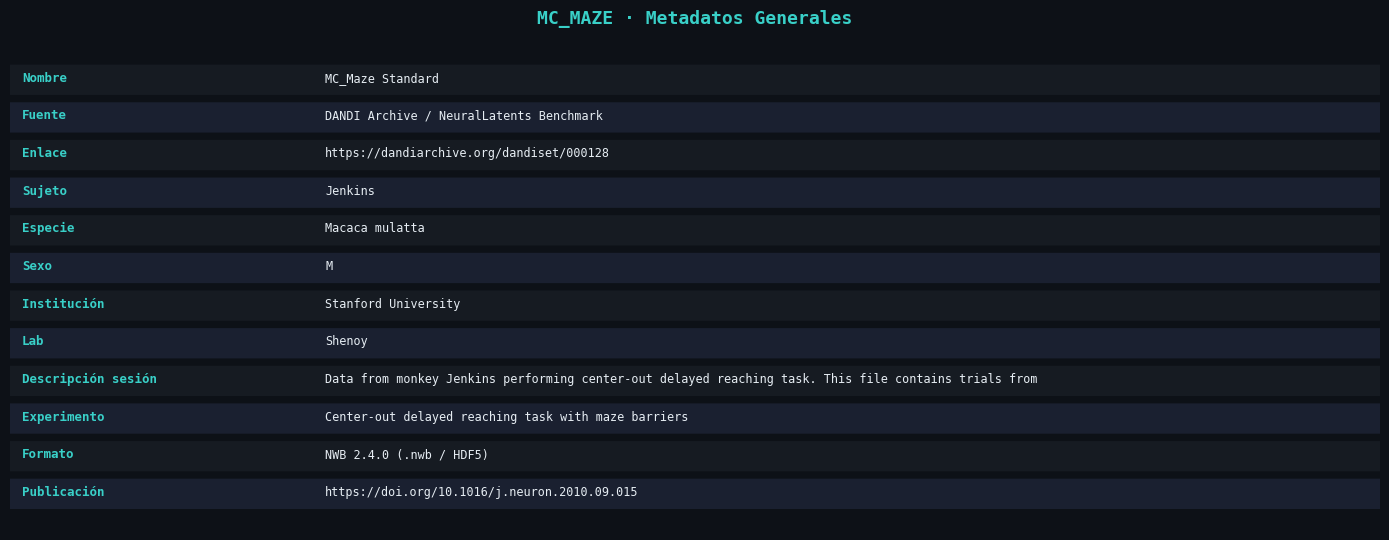

✓ 01_metadata_table.png


In [6]:
#@title 1. Tabla de metadatos generales
def decode(x):
    if isinstance(x, bytes): return x.decode()
    if hasattr(x, '__iter__') and not isinstance(x, str):
        try: return ', '.join([i.decode() if isinstance(i, bytes) else str(i) for i in x])
        except: pass
    return str(x)

def get(f, key):
    try:
        val = f[key][()]
        return decode(val)
    except: return 'N/A'

meta_rows = [
    ('Nombre',             'MC_Maze Standard'),
    ('Fuente',             'DANDI Archive / NeuralLatents Benchmark'),
    ('Enlace',             'https://dandiarchive.org/dandiset/000128'),
    ('Sujeto',             get(f_train, 'general/subject/subject_id')),
    ('Especie',            get(f_train, 'general/subject/species')),
    ('Sexo',               get(f_train, 'general/subject/sex')),
    ('Institución',        get(f_train, 'general/institution')),
    ('Lab',                get(f_train, 'general/lab')),
    ('Descripción sesión', get(f_train, 'session_description')),
    ('Experimento',        get(f_train, 'general/experiment_description')),
    ('Formato',            'NWB 2.4.0 (.nwb / HDF5)'),
    ('Publicación',        get(f_train, 'general/related_publications')),
]

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.axis('off')
fig.patch.set_facecolor(C['bg'])

col_w = [0.22, 0.78]
for r, (k, v) in enumerate(meta_rows):
    y = 1 - (r + 1) / (len(meta_rows) + 1)
    bg_c = C['panel'] if r % 2 == 0 else '#1a2030'
    ax.add_patch(FancyBboxPatch((0, y - 0.032), 1, 0.058,
                                boxstyle='round,pad=0.002',
                                facecolor=bg_c, edgecolor='none',
                                transform=ax.transAxes, zorder=0))
    ax.text(col_w[0] * 0.04, y, k, transform=ax.transAxes,
            color=C['teal'], fontsize=9, fontweight='bold', va='center')
    ax.text(col_w[0] + 0.01, y, v[:100], transform=ax.transAxes,
            color=C['white'], fontsize=8.5, va='center')

ax.set_title('MC_MAZE · Metadatos Generales', color=C['teal'],
             fontsize=13, fontweight='bold', pad=12)
ax.axhline(y=0, color=C['border'], lw=0.5)
plt.tight_layout()
plt.savefig(f'{OUT}/01_metadata_table.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 01_metadata_table.png')

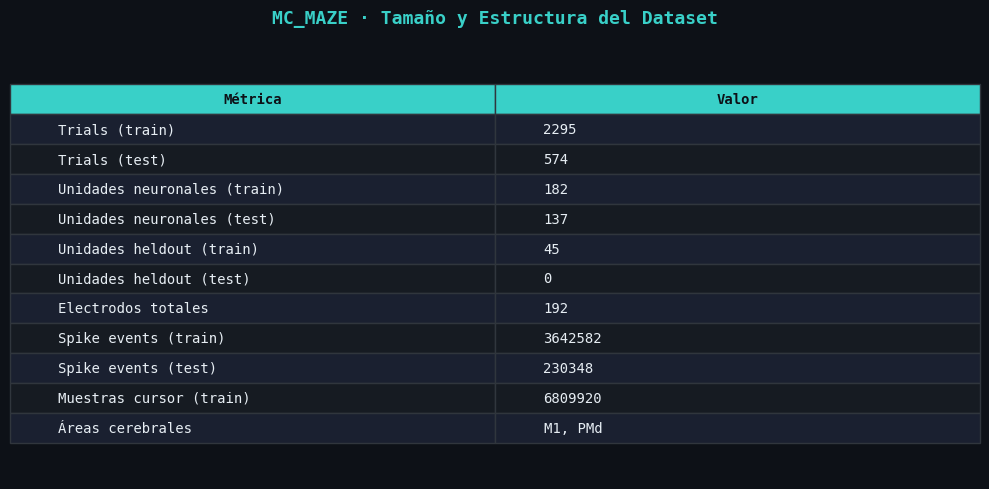

✓ 02_size_structure.png


In [7]:
#@title 2. Tamaño y estructura
n_units_train  = len(f_train['units/id'][()])
n_units_test   = len(f_test['units/id'][()])

# Trials
n_trials_train = len(f_train['intervals/trials/id'][()])
n_trials_test  = len(f_test['intervals/trials/id'][()])

# Electrodos
n_elec = len(f_train['general/extracellular_ephys/electrodes/id'][()])

# Spike times
n_spikes_train = len(f_train['units/spike_times'][()])
n_spikes_test  = len(f_test['units/spike_times'][()])

# Muestras de comportamiento
n_cursor_train = len(f_train['processing/behavior/cursor_pos/data'][()])

# Held-out units
n_heldout_train = int(np.sum(f_train['units/heldout'][()]))
n_heldout_test  = int(np.sum(f_test['units/heldout'][()]))

size_data = {
    'Métrica': [
        'Trials (train)', 'Trials (test)',
        'Unidades neuronales (train)', 'Unidades neuronales (test)',
        'Unidades heldout (train)', 'Unidades heldout (test)',
        'Electrodos totales',
        'Spike events (train)', 'Spike events (test)',
        'Muestras cursor (train)',
        'Áreas cerebrales',
    ],
    'Valor': [
        n_trials_train, n_trials_test,
        n_units_train, n_units_test,
        n_heldout_train, n_heldout_test,
        n_elec,
        n_spikes_train, n_spikes_test,
        n_cursor_train,
        'M1, PMd',
    ]
}

df_size = pd.DataFrame(size_data)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
fig.patch.set_facecolor(C['bg'])

tbl = ax.table(
    cellText=df_size.values,
    colLabels=df_size.columns,
    loc='center',
    cellLoc='left',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(C['border'])
    if r == 0:
        cell.set_facecolor(C['teal'])
        cell.set_text_props(color=C['bg'], fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor(C['panel'])
        cell.set_text_props(color=C['white'])
    else:
        cell.set_facecolor('#1a2030')
        cell.set_text_props(color=C['white'])

ax.set_title('MC_MAZE · Tamaño y Estructura del Dataset',
             color=C['teal'], fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig(f'{OUT}/02_size_structure.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 02_size_structure.png')

#3. Distribución de Data

In [8]:
move_onset   = f_train['intervals/trials/move_onset_time'][()]
cursor_ts    = f_train['processing/behavior/cursor_pos/timestamps'][()]
cursor_pos   = f_train['processing/behavior/cursor_pos/data'][()]
hand_vel = f_train['processing/behavior/hand_vel/data'][()]
vel_ts = f_train['processing/behavior/hand_vel/timestamps'][()]

vx = hand_vel[:, 0]
vy = hand_vel[:, 1]
angles = []

first_change_times = []

for i in range(len(move_onset)):
    onset = move_onset[i]
    mask = (vel_ts >= onset) & (vel_ts < onset + 1.0)

    vx_trial = vx[mask]
    vy_trial = vy[mask]
    ts_trial = vel_ts[mask]

    sc_x = np.diff(np.sign(vx_trial))
    sc_y = np.diff(np.sign(vy_trial))
    changes = np.where((sc_x != 0) | (sc_y != 0))[0]

    if len(changes) > 0:
        dt = ts_trial[changes[0]] - onset
        first_change_times.append(dt)

first_change_times = np.array(first_change_times)

print(f'Trials con cambio detectado: {len(first_change_times)} / {len(move_onset)}')
print(f'Media:    {np.mean(first_change_times)*1000:.1f} ms')
print(f'Mediana:  {np.median(first_change_times)*1000:.1f} ms')
print(f'P90:      {np.percentile(first_change_times, 90)*1000:.1f} ms')
print(f'P95:      {np.percentile(first_change_times, 95)*1000:.1f} ms')
print(f'Máximo:   {np.max(first_change_times)*1000:.1f} ms')

Trials con cambio detectado: 2295 / 2295
Media:    119.0 ms
Mediana:  88.0 ms
P90:      272.0 ms
P95:      297.0 ms
Máximo:   393.0 ms


Trials válidos: 2295 / 2295


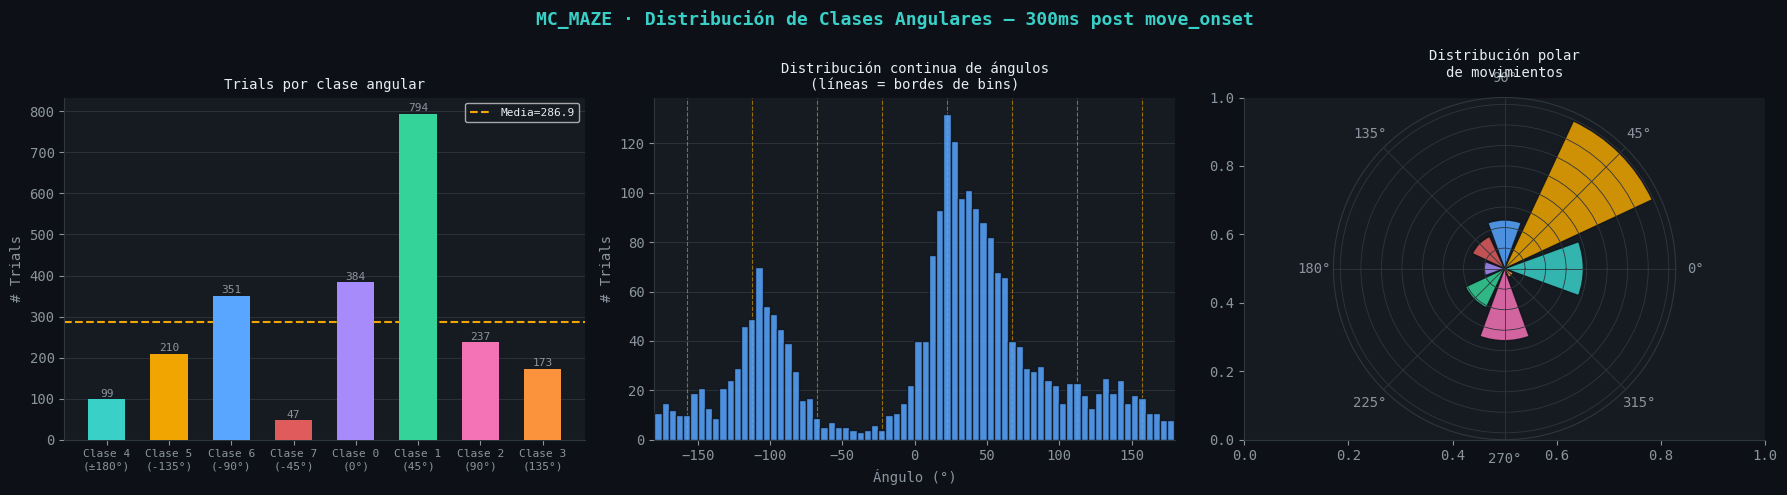

✓ 03b_angular_class_distribution.png

Ventana de clasificación: 500ms post move_onset (50 muestras @ 100Hz)

Distribución de clases angulares:
  Clase 4 (±180°)      →   99 trials (4.3%)
  Clase 5 (-135°)      →  210 trials (9.2%)
  Clase 6 (-90°)       →  351 trials (15.3%)
  Clase 7 (-45°)       →   47 trials (2.0%)
  Clase 0 (0°)         →  384 trials (16.7%)
  Clase 1 (45°)        →  794 trials (34.6%)
  Clase 2 (90°)        →  237 trials (10.3%)
  Clase 3 (135°)       →  173 trials (7.5%)

  Total trials válidos    : 2295
  Clases encontradas      : 8/8
  Balance (std/mean)      : 0.765  (0=perfecto)


In [9]:
#@title 3.1 Distribución de clases angulares

move_onset   = f_train['intervals/trials/move_onset_time'][()]
cursor_ts    = f_train['processing/behavior/cursor_pos/timestamps'][()]
cursor_pos   = f_train['processing/behavior/cursor_pos/data'][()]

# ── Calcular ángulo por trial ──────────────────────────────────────────────
# Ventana: 500ms después de move_onset = 50 muestras a 100Hz
WINDOW_SAMPLES = 50

angles_deg = []
for i in range(len(move_onset)):
    idx_start = np.searchsorted(cursor_ts, move_onset[i])
    idx_end   = idx_start + WINDOW_SAMPLES

    # Verificar que no nos salimos del array
    if idx_end >= len(cursor_pos):
        angles_deg.append(np.nan)
        continue

    hand_start = cursor_pos[idx_start]
    hand_end   = cursor_pos[idx_end]

    dx = hand_end[0] - hand_start[0]
    dy = hand_end[1] - hand_start[1]
    angles_deg.append(np.degrees(np.arctan2(dy, dx)))

angles_deg = np.array(angles_deg)

# Descartar NaN (trials al borde del array)
valid_mask = ~np.isnan(angles_deg)
angles_deg = angles_deg[valid_mask]
print(f'Trials válidos: {valid_mask.sum()} / {len(valid_mask)}')

# ── Asignar a 8 clases ────────────────────────────────────────────────────
bin_edges  = np.array([-180, -157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5, 180])
bin_labels = ['Clase 4\n(±180°)', 'Clase 5\n(-135°)', 'Clase 6\n(-90°)', 'Clase 7\n(-45°)',
              'Clase 0\n(0°)',    'Clase 1\n(45°)',   'Clase 2\n(90°)',  'Clase 3\n(135°)']

angles_clipped = np.clip(angles_deg, -179.99, 179.99)
bin_idx        = np.digitize(angles_clipped, bin_edges[1:-1]) % 8  # 0..7

# ── Contar por clase ──────────────────────────────────────────────────────
unique_bins, counts = np.unique(bin_idx, return_counts=True)

# ── Figura ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('MC_MAZE · Distribución de Clases Angulares — 300ms post move_onset',
             color=C['teal'], fontsize=13, fontweight='bold')

colors_8 = [C['teal'], C['amber'], C['blue'], C['red'],
            '#a78bfa', '#34d399', '#f472b6', '#fb923c']

# 3b.1 — Barras por clase
ax = axes[0]
bars = ax.bar([bin_labels[b] for b in unique_bins],
              counts,
              color=[colors_8[b] for b in unique_bins],
              width=0.6, zorder=3)
ax.axhline(counts.mean(), color=C['amber'], lw=1.5, ls='--',
           label=f'Media={counts.mean():.1f}')
ax.set_title('Trials por clase angular', color=C['white'], fontsize=10)
ax.set_ylabel('# Trials', color=C['gray'])
ax.tick_params(axis='x', labelsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', zorder=0)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', va='bottom', fontsize=8, color=C['gray'])

# 3b.2 — Histograma continuo de ángulos
ax = axes[1]
ax.hist(angles_deg, bins=72, color=C['blue'], alpha=0.85,
        edgecolor=C['bg'], zorder=3)
for edge in bin_edges[1:-1]:
    ax.axvline(edge, color=C['amber'], lw=0.8, ls='--', alpha=0.6)
ax.set_title('Distribución continua de ángulos\n(líneas = bordes de bins)',
             color=C['white'], fontsize=10)
ax.set_xlabel('Ángulo (°)', color=C['gray'])
ax.set_ylabel('# Trials', color=C['gray'])
ax.set_xlim(-180, 180)
ax.grid(axis='y', zorder=0)

# 3b.3 — Polar
ax = fig.add_subplot(1, 3, 3, projection='polar')
ax.set_facecolor(C['panel'])
theta_centers = np.radians([0, 45, 90, 135, 180, -135, -90, -45])
polar_order   = [4, 5, 6, 7, 0, 1, 2, 3]
counts_polar  = np.array([counts[list(unique_bins).index(b)]
                           if b in unique_bins else 0
                           for b in polar_order])
ax.bar(theta_centers, counts_polar,
       width=np.radians(40), bottom=0,
       color=colors_8, alpha=0.85, edgecolor=C['bg'])
ax.set_title('Distribución polar\nde movimientos', color=C['white'],
             fontsize=10, pad=15)
ax.tick_params(colors=C['gray'])
ax.set_yticklabels([])
ax.spines['polar'].set_color(C['border'])

plt.tight_layout()
plt.savefig(f'{OUT}/03b_angular_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Resumen ───────────────────────────────────────────────────────────────
print('✓ 03b_angular_class_distribution.png')
print(f'\nVentana de clasificación: 500ms post move_onset (50 muestras @ 100Hz)')
print(f'\nDistribución de clases angulares:')
for b, cnt in zip(unique_bins, counts):
    print(f'  {bin_labels[b].replace(chr(10)," "):20s} → {cnt:4d} trials ({cnt/len(angles_deg)*100:.1f}%)')
print(f'\n  Total trials válidos    : {len(angles_deg)}')
print(f'  Clases encontradas      : {len(unique_bins)}/8')
print(f'  Balance (std/mean)      : {counts.std()/counts.mean():.3f}  (0=perfecto)')

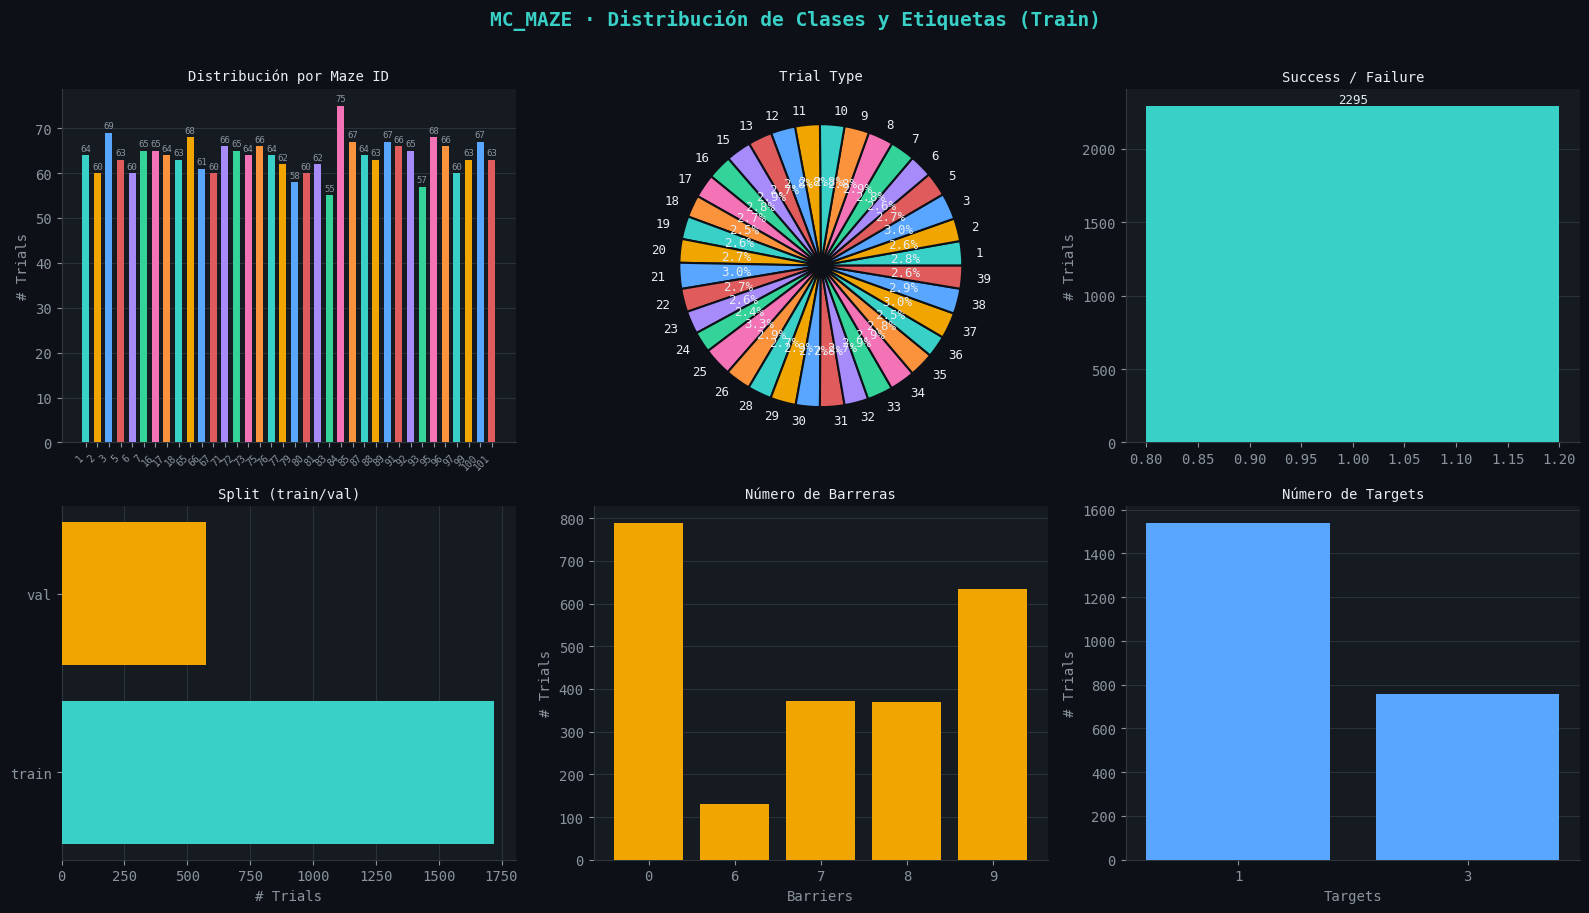

✓ 03_class_distribution.png


In [10]:
#@title 3.2. Distribución de trials
maze_ids      = f_train['intervals/trials/maze_id'][()]
trial_types   = f_train['intervals/trials/trial_type'][()]
success       = f_train['intervals/trials/success'][()]
split         = f_train['intervals/trials/split'][()]
num_barriers  = f_train['intervals/trials/num_barriers'][()]
num_targets   = f_train['intervals/trials/num_targets'][()]

def to_str_arr(arr):
    if arr.dtype.kind in ('S', 'O', 'U'):
        return [x.decode() if isinstance(x, bytes) else str(x) for x in arr]
    return arr

maze_ids_s    = to_str_arr(maze_ids)
trial_types_s = to_str_arr(trial_types)
split_s       = to_str_arr(split)
success_s     = to_str_arr(success)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('MC_MAZE · Distribución de Clases y Etiquetas (Train)',
             color=C['teal'], fontsize=14, fontweight='bold', y=1.01)

colors_cycle = [C['teal'], C['amber'], C['blue'], C['red'],
                '#a78bfa', '#34d399', '#f472b6', '#fb923c']

# 3.1 Maze ID
ax = axes[0, 0]
u, c = np.unique(maze_ids_s, return_counts=True)
bars = ax.bar(range(len(u)), c, color=colors_cycle[:len(u)], width=0.6, zorder=3)
ax.set_xticks(range(len(u))); ax.set_xticklabels(u, rotation=45, ha='right', fontsize=7)
ax.set_title('Distribución por Maze ID', color=C['white'], fontsize=10)
ax.set_ylabel('# Trials', color=C['gray'])
ax.grid(axis='y', zorder=0)
for bar, cnt in zip(bars, c):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', va='bottom', fontsize=6.5, color=C['gray'])

# 3.2 Trial type
ax = axes[0, 1]
u2, c2 = np.unique(trial_types_s, return_counts=True)
ax.pie(c2, labels=u2, colors=colors_cycle[:len(u2)],
       autopct='%1.1f%%', textprops={'color': C['white'], 'fontsize': 9},
       wedgeprops={'edgecolor': C['bg'], 'linewidth': 1.5})
ax.set_title('Trial Type', color=C['white'], fontsize=10)

# 3.3 Success
ax = axes[0, 2]
u3, c3 = np.unique(success_s, return_counts=True)
bars3 = ax.bar(u3, c3,
               color=[C['teal'] if str(v) in ('1', 'True', 'b"1"') else C['red'] for v in u3],
               width=0.4, zorder=3)
ax.set_title('Success / Failure', color=C['white'], fontsize=10)
ax.set_ylabel('# Trials', color=C['gray'])
ax.grid(axis='y', zorder=0)
for bar, cnt in zip(bars3, c3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', va='bottom', fontsize=9, color=C['white'])

# 3.4 Split
ax = axes[1, 0]
u4, c4 = np.unique(split_s, return_counts=True)
ax.barh(u4, c4, color=colors_cycle[:len(u4)], zorder=3)
ax.set_title('Split (train/val)', color=C['white'], fontsize=10)
ax.set_xlabel('# Trials', color=C['gray'])
ax.grid(axis='x', zorder=0)

# 3.5 Num barriers
ax = axes[1, 1]
u5, c5 = np.unique(num_barriers, return_counts=True)
ax.bar(u5.astype(str), c5, color=C['amber'], zorder=3)
ax.set_title('Número de Barreras', color=C['white'], fontsize=10)
ax.set_ylabel('# Trials', color=C['gray'])
ax.set_xlabel('Barriers', color=C['gray'])
ax.grid(axis='y', zorder=0)

# 3.6 Num targets
ax = axes[1, 2]
u6, c6 = np.unique(num_targets, return_counts=True)
ax.bar(u6.astype(str), c6, color=C['blue'], zorder=3)
ax.set_title('Número de Targets', color=C['white'], fontsize=10)
ax.set_ylabel('# Trials', color=C['gray'])
ax.set_xlabel('Targets', color=C['gray'])
ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig(f'{OUT}/03_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 03_class_distribution.png')

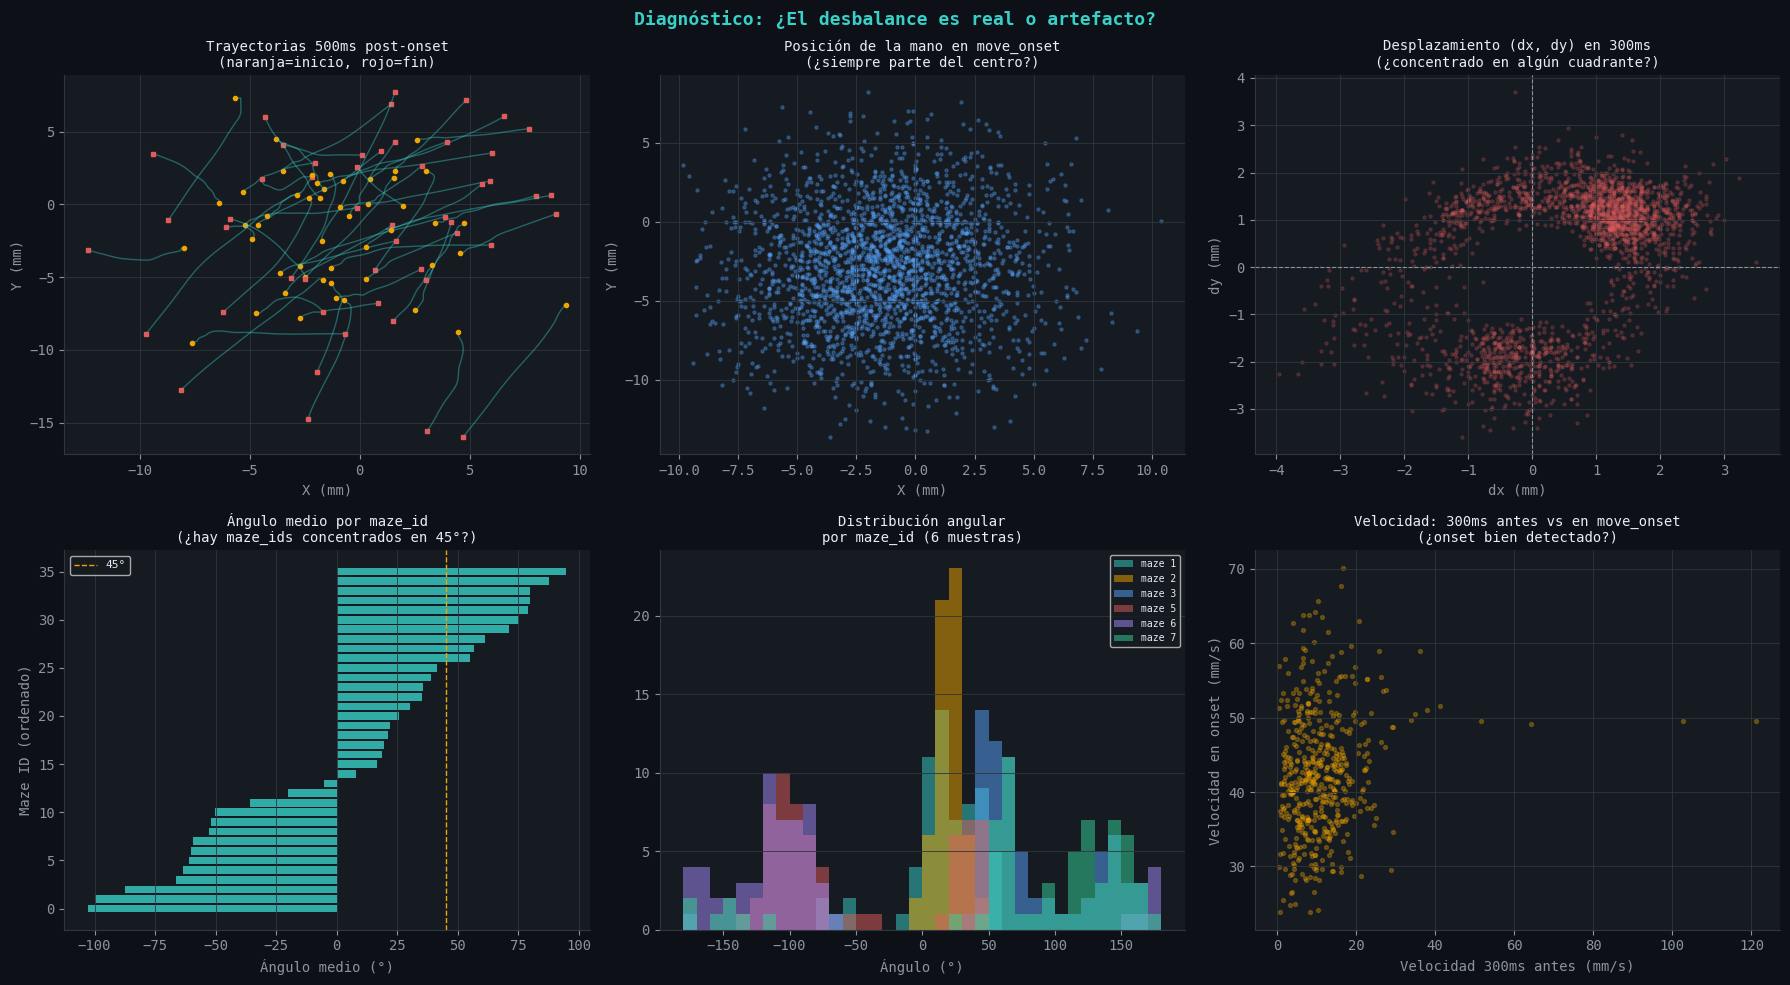

✓ diagnostico_move_onset.png


In [11]:
#@title 3.3 Orientaciones iniciales iniciales

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('Diagnóstico: ¿El desbalance es real o artefacto?',
             color=C['teal'], fontsize=13, fontweight='bold')

# ── 1. Trayectorias reales de los primeros 50 trials ─────────────────────
# Para ver visualmente hacia dónde va la mano después del move_onset
ax = axes[0, 0]
ax.set_facecolor(C['panel'])
for i in range(min(50, len(move_onset))):
    idx_start = np.searchsorted(cursor_ts, move_onset[i])
    idx_end   = idx_start + 50  # 500ms
    if idx_end >= len(cursor_pos):
        continue
    traj = cursor_pos[idx_start:idx_end]
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.4, lw=1, color=C['teal'])
    ax.plot(traj[0, 0], traj[0, 1], 'o', ms=3, color=C['amber'])  # inicio
    ax.plot(traj[-1, 0], traj[-1, 1], 's', ms=3, color=C['red'])  # fin
ax.set_title('Trayectorias 500ms post-onset\n(naranja=inicio, rojo=fin)',
             color=C['white'], fontsize=10)
ax.set_xlabel('X (mm)', color=C['gray'])
ax.set_ylabel('Y (mm)', color=C['gray'])
ax.grid(zorder=0)

# ── 2. Posición de la mano en move_onset (¿parte siempre del centro?) ────
ax = axes[0, 1]
ax.set_facecolor(C['panel'])
onset_positions = []
for i in range(len(move_onset)):
    idx = np.searchsorted(cursor_ts, move_onset[i])
    if idx < len(cursor_pos):
        onset_positions.append(cursor_pos[idx])
onset_positions = np.array(onset_positions)
ax.scatter(onset_positions[:, 0], onset_positions[:, 1],
           alpha=0.3, s=5, color=C['blue'])
ax.set_title('Posición de la mano en move_onset\n(¿siempre parte del centro?)',
             color=C['white'], fontsize=10)
ax.set_xlabel('X (mm)', color=C['gray'])
ax.set_ylabel('Y (mm)', color=C['gray'])
ax.grid(zorder=0)

# ── 3. Distribución de desplazamientos dx y dy por separado ──────────────
ax = axes[0, 2]
ax.set_facecolor(C['panel'])
dx_vals = []
dy_vals = []
for i in range(len(move_onset)):
    idx_start = np.searchsorted(cursor_ts, move_onset[i])
    idx_end   = idx_start + 30
    if idx_end >= len(cursor_pos):
        continue
    dx_vals.append(cursor_pos[idx_end, 0] - cursor_pos[idx_start, 0])
    dy_vals.append(cursor_pos[idx_end, 1] - cursor_pos[idx_start, 1])
dx_vals = np.array(dx_vals)
dy_vals = np.array(dy_vals)
ax.scatter(dx_vals, dy_vals, alpha=0.2, s=5, color=C['red'])
ax.axhline(0, color=C['gray'], lw=0.8, ls='--')
ax.axvline(0, color=C['gray'], lw=0.8, ls='--')
ax.set_title('Desplazamiento (dx, dy) en 300ms\n(¿concentrado en algún cuadrante?)',
             color=C['white'], fontsize=10)
ax.set_xlabel('dx (mm)', color=C['gray'])
ax.set_ylabel('dy (mm)', color=C['gray'])
ax.grid(zorder=0)

# ── 4. Ángulo por maze_id (¿un maze_id domina la Clase 1?) ───────────────
ax = axes[1, 0]
ax.set_facecolor(C['panel'])
maze_ids_valid = maze_ids[valid_mask] if 'valid_mask' in dir() else maze_ids[:len(angles_deg)]
# Ángulo medio por maze_id
df_angle = pd.DataFrame({'maze_id': maze_ids_valid, 'angle': angles_deg})
mean_angle_per_maze = df_angle.groupby('maze_id')['angle'].mean().sort_values()
ax.barh(range(len(mean_angle_per_maze)), mean_angle_per_maze.values,
        color=C['teal'], alpha=0.8)
ax.set_title('Ángulo medio por maze_id\n(¿hay maze_ids concentrados en 45°?)',
             color=C['white'], fontsize=10)
ax.set_xlabel('Ángulo medio (°)', color=C['gray'])
ax.set_ylabel('Maze ID (ordenado)', color=C['gray'])
ax.axvline(45, color=C['amber'], lw=1, ls='--', label='45°')
ax.legend(fontsize=8)
ax.grid(axis='x', zorder=0)

# ── 5. Histograma de ángulos separado por maze_id (muestra 6 maze_ids) ───
ax = axes[1, 1]
ax.set_facecolor(C['panel'])
sample_mazes = np.unique(maze_ids_valid)[:6]
for maze, col in zip(sample_mazes, [C['teal'], C['amber'], C['blue'],
                                     C['red'], '#a78bfa', '#34d399']):
    mask_m = maze_ids_valid == maze
    ax.hist(angles_deg[mask_m], bins=36, alpha=0.5,
            label=f'maze {maze}', color=col, range=(-180, 180))
ax.set_title('Distribución angular\npor maze_id (6 muestras)',
             color=C['white'], fontsize=10)
ax.set_xlabel('Ángulo (°)', color=C['gray'])
ax.legend(fontsize=7)
ax.grid(axis='y', zorder=0)

# ── 6. move_onset timing: ¿está bien detectado? ──────────────────────────
ax = axes[1, 2]
ax.set_facecolor(C['panel'])
# Velocidad de la mano en move_onset vs 300ms antes
speeds_at_onset = []
speeds_before   = []
hand_vel = f_train['processing/behavior/hand_vel/data'][()]
for i in range(min(500, len(move_onset))):
    idx = np.searchsorted(cursor_ts, move_onset[i])
    if idx >= 5 and idx + 5 < len(hand_vel):
        v_at    = np.linalg.norm(hand_vel[idx])
        v_before = np.linalg.norm(hand_vel[idx - 30])  # 300ms antes
        speeds_at_onset.append(v_at)
        speeds_before.append(v_before)
ax.scatter(speeds_before, speeds_at_onset, alpha=0.3, s=8, color=C['amber'])
ax.set_title('Velocidad: 300ms antes vs en move_onset\n(¿onset bien detectado?)',
             color=C['white'], fontsize=10)
ax.set_xlabel('Velocidad 300ms antes (mm/s)', color=C['gray'])
ax.set_ylabel('Velocidad en onset (mm/s)', color=C['gray'])
ax.grid(zorder=0)

plt.tight_layout()
plt.savefig(f'{OUT}/diagnostico_move_onset.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ diagnostico_move_onset.png')

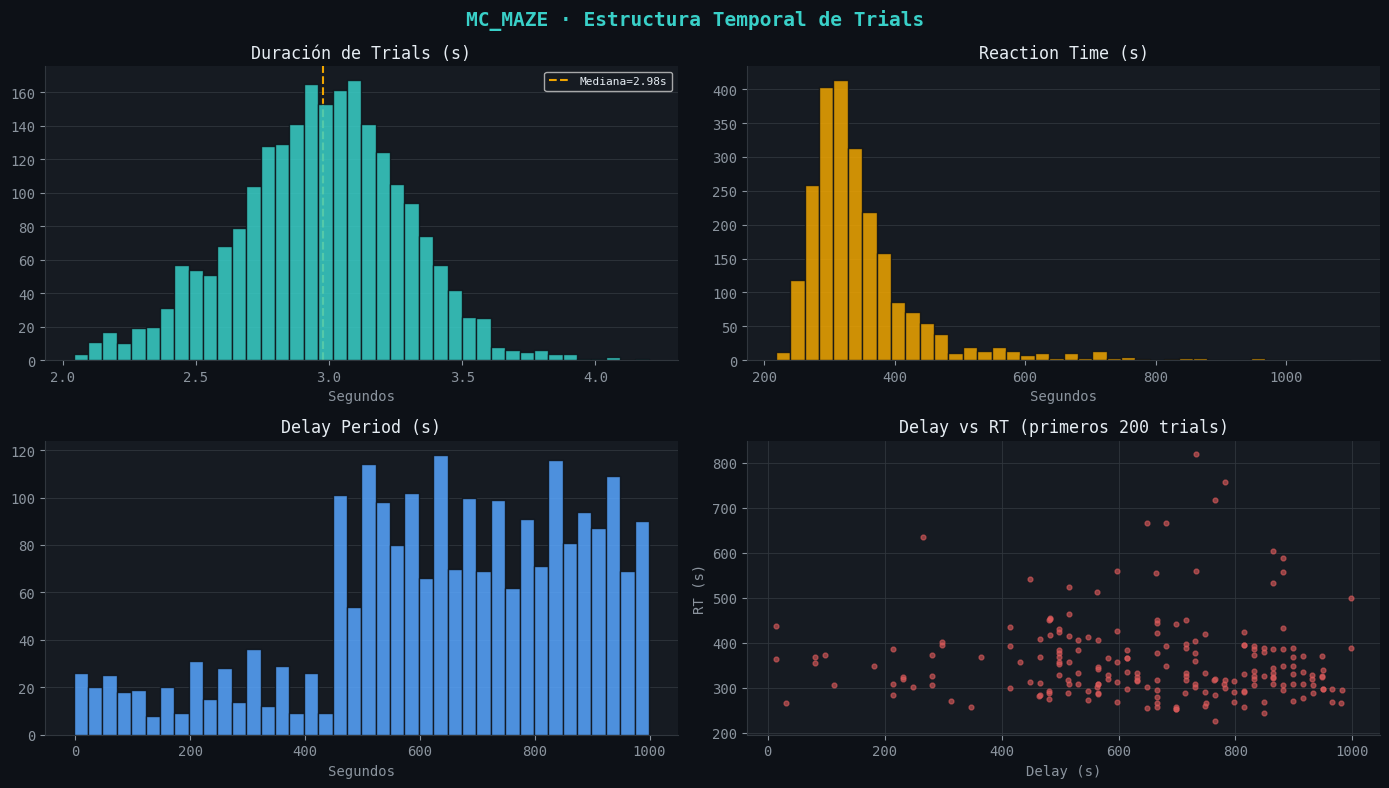

✓ 04_trial_timing.png


In [12]:
#@title 4. Estructura temporal de trials
start_times   = f_train['intervals/trials/start_time'][()]
stop_times    = f_train['intervals/trials/stop_time'][()]
go_cue        = f_train['intervals/trials/go_cue_time'][()]
move_onset    = f_train['intervals/trials/move_onset_time'][()]
rt            = f_train['intervals/trials/rt'][()]
delay         = f_train['intervals/trials/delay'][()]

durations = stop_times - start_times

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('MC_MAZE · Estructura Temporal de Trials',
             color=C['teal'], fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(durations, bins=40, color=C['teal'], alpha=0.85, edgecolor=C['bg'], zorder=3)
ax.axvline(np.median(durations), color=C['amber'], lw=1.5, ls='--',
           label=f'Mediana={np.median(durations):.2f}s')
ax.set_title('Duración de Trials (s)', color=C['white'])
ax.set_xlabel('Segundos', color=C['gray'])
ax.legend(fontsize=8)
ax.grid(axis='y', zorder=0)

ax = axes[0, 1]
ax.hist(rt[~np.isnan(rt)], bins=40, color=C['amber'], alpha=0.85,
        edgecolor=C['bg'], zorder=3)
ax.set_title('Reaction Time (s)', color=C['white'])
ax.set_xlabel('Segundos', color=C['gray'])
ax.grid(axis='y', zorder=0)

ax = axes[1, 0]
ax.hist(delay[~np.isnan(delay)], bins=40, color=C['blue'], alpha=0.85,
        edgecolor=C['bg'], zorder=3)
ax.set_title('Delay Period (s)', color=C['white'])
ax.set_xlabel('Segundos', color=C['gray'])
ax.grid(axis='y', zorder=0)

ax = axes[1, 1]
ax.scatter(delay[:200], rt[:200], alpha=0.6, s=12, color=C['red'], zorder=3)
ax.set_title('Delay vs RT (primeros 200 trials)', color=C['white'])
ax.set_xlabel('Delay (s)', color=C['gray'])
ax.set_ylabel('RT (s)', color=C['gray'])
ax.grid(zorder=0)

plt.tight_layout()
plt.savefig(f'{OUT}/04_trial_timing.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 04_trial_timing.png')

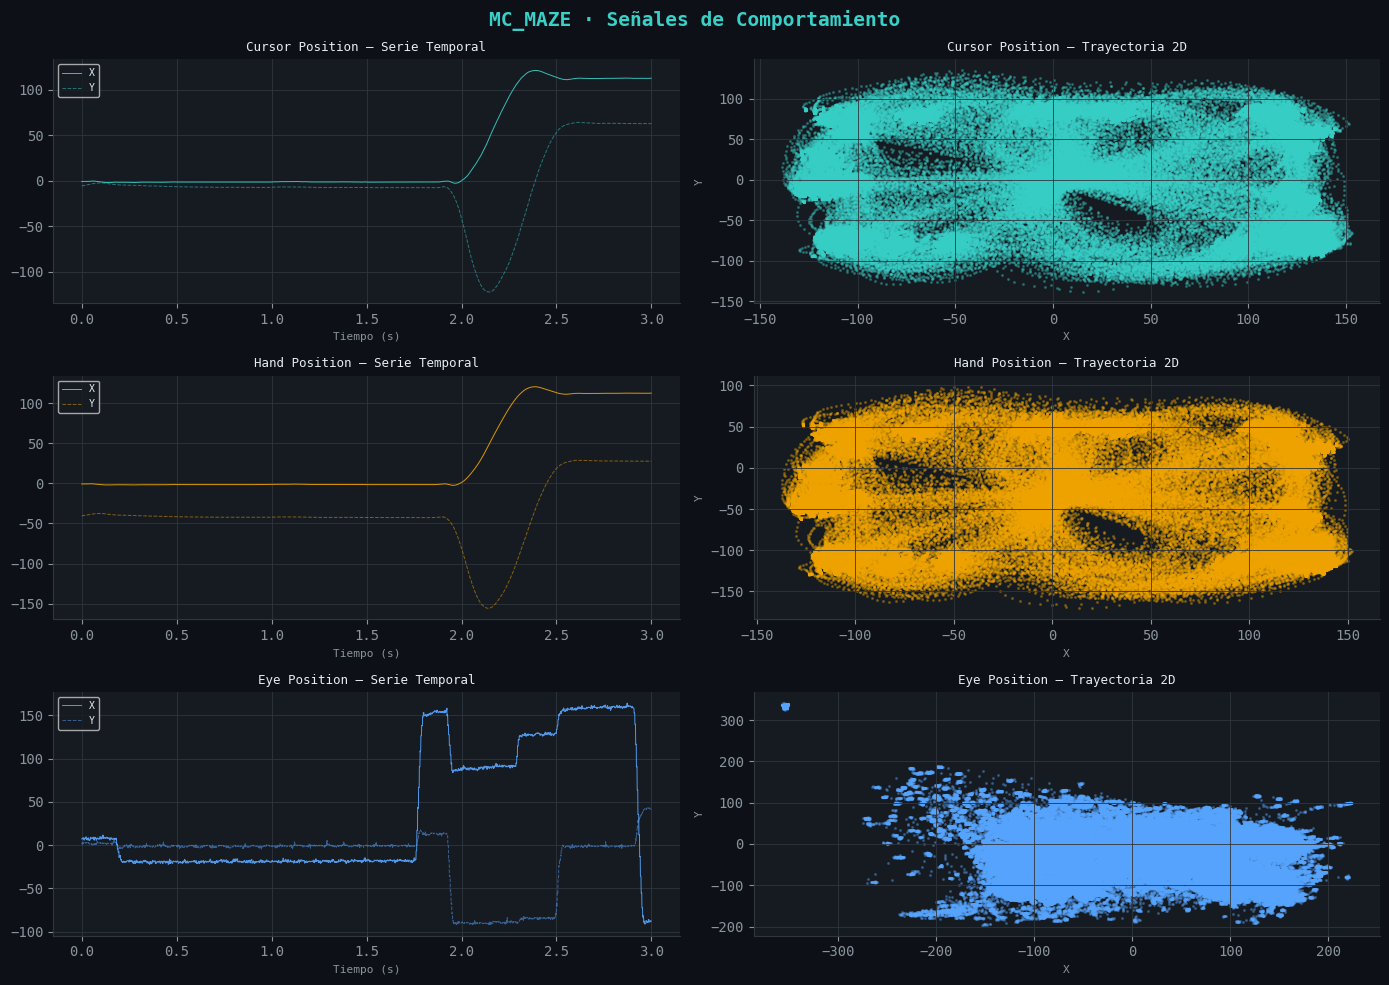

✓ 05_behavior_signals.png


In [13]:
#@title 5. Comportamiento: cursor, mano, ojo
cursor_pos = f_train['processing/behavior/cursor_pos/data'][()]
hand_pos   = f_train['processing/behavior/hand_pos/data'][()]
eye_pos    = f_train['processing/behavior/eye_pos/data'][()]
c_ts       = f_train['processing/behavior/cursor_pos/timestamps'][()]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('MC_MAZE · Señales de Comportamiento',
             color=C['teal'], fontsize=14, fontweight='bold')

signals = [
    (cursor_pos, 'Cursor Position', C['teal']),
    (hand_pos,   'Hand Position',   C['amber']),
    (eye_pos,    'Eye Position',    C['blue']),
]
n_show = min(3000, len(c_ts))
t_show = c_ts[:n_show] - c_ts[0]

for i, (sig, label, col) in enumerate(signals):
    ax_t = axes[i, 0]
    ax_s = axes[i, 1]
    ax_t.plot(t_show, sig[:n_show, 0], color=col, lw=0.7, alpha=0.9, label='X')
    ax_t.plot(t_show, sig[:n_show, 1], color=col, lw=0.7, alpha=0.5, ls='--', label='Y')
    ax_t.set_title(f'{label} — Serie Temporal', color=C['white'], fontsize=9)
    ax_t.set_xlabel('Tiempo (s)', color=C['gray'], fontsize=8)
    ax_t.legend(fontsize=7); ax_t.grid(zorder=0)

    ax_s.scatter(sig[::10, 0], sig[::10, 1], s=1.5, color=col, alpha=0.3)
    ax_s.set_title(f'{label} — Trayectoria 2D', color=C['white'], fontsize=9)
    ax_s.set_xlabel('X', color=C['gray'], fontsize=8)
    ax_s.set_ylabel('Y', color=C['gray'], fontsize=8)
    ax_s.grid(zorder=0)

plt.tight_layout()
plt.savefig(f'{OUT}/05_behavior_signals.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 05_behavior_signals.png')

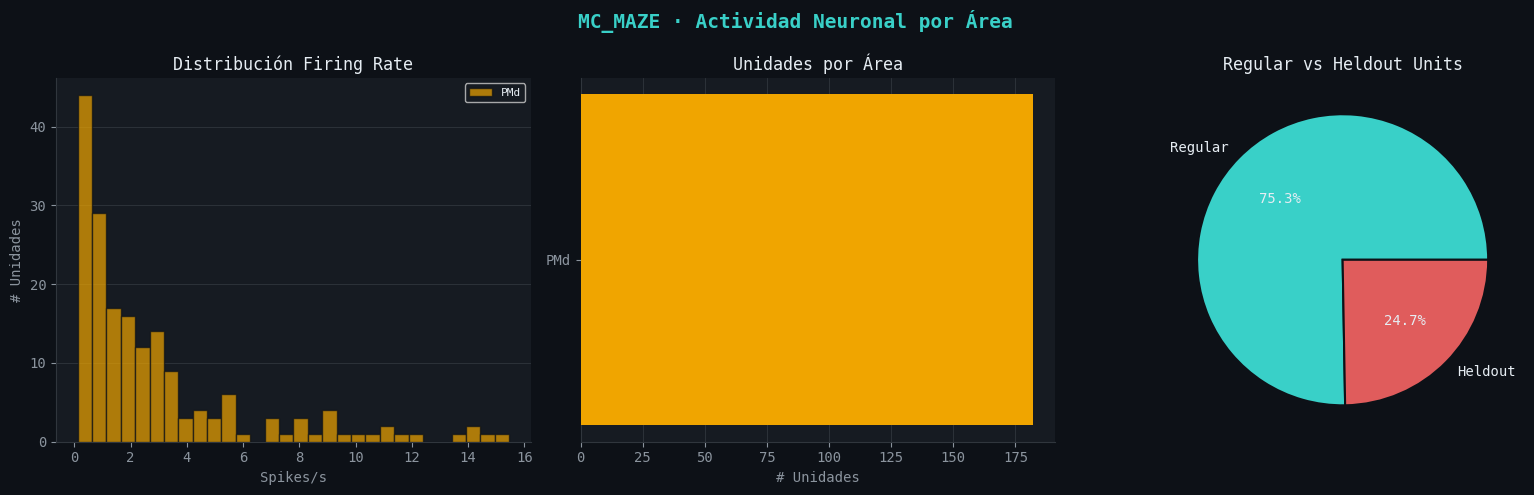

✓ 06_neural_activity.png


In [14]:
#@title 6. Actividad neuronal: firing rates y distribución por área
spike_times  = f_train['units/spike_times'][()]
spike_idx    = f_train['units/spike_times_index'][()]
heldout      = f_train['units/heldout'][()]
elec_ids     = f_train['units/electrodes'][()]
locations    = f_train['general/extracellular_ephys/electrodes/location'][()]
loc_decoded  = [x.decode() if isinstance(x, bytes) else str(x) for x in locations]

# Calcular firing rates por unidad
session_dur  = float(stop_times[-1] - start_times[0])
unit_spk_counts = []
prev = 0
for idx in spike_idx:
    unit_spk_counts.append(int(idx) - prev)
    prev = int(idx)
firing_rates = np.array(unit_spk_counts) / session_dur

# Área por unidad (a través de electrodo)
unit_areas = []
for eid in elec_ids:
    lbl = loc_decoded[eid] if eid < len(loc_decoded) else 'Unknown'
    unit_areas.append(lbl)

df_units = pd.DataFrame({
    'unit_id':     range(len(firing_rates)),
    'firing_rate': firing_rates,
    'area':        unit_areas,
    'heldout':     heldout.astype(bool),
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('MC_MAZE · Actividad Neuronal por Área',
             color=C['teal'], fontsize=14, fontweight='bold')

area_colors = {'M1': C['teal'], 'PMd': C['amber'],
               'M1,PMd': C['blue'], 'Unknown': C['gray']}

# 6.1 Firing rate distribution
ax = axes[0]
for area, grp in df_units.groupby('area'):
    col = area_colors.get(area, C['gray'])
    ax.hist(grp['firing_rate'], bins=30, alpha=0.7, label=area,
            color=col, edgecolor=C['bg'], zorder=3)
ax.set_title('Distribución Firing Rate', color=C['white'])
ax.set_xlabel('Spikes/s', color=C['gray'])
ax.set_ylabel('# Unidades', color=C['gray'])
ax.legend(fontsize=8); ax.grid(axis='y', zorder=0)

# 6.2 Conteo por área
ax = axes[1]
area_counts = df_units.groupby('area').size()
ax.barh(area_counts.index, area_counts.values,
        color=[area_colors.get(a, C['gray']) for a in area_counts.index], zorder=3)
ax.set_title('Unidades por Área', color=C['white'])
ax.set_xlabel('# Unidades', color=C['gray'])
ax.grid(axis='x', zorder=0)

# 6.3 Heldout vs regular
ax = axes[2]
ho_counts = df_units['heldout'].value_counts()
labels    = ['Regular', 'Heldout']
vals      = [ho_counts.get(False, 0), ho_counts.get(True, 0)]
ax.pie(vals, labels=labels, colors=[C['teal'], C['red']],
       autopct='%1.1f%%', textprops={'color': C['white'], 'fontsize': 10},
       wedgeprops={'edgecolor': C['bg'], 'linewidth': 1.5})
ax.set_title('Regular vs Heldout Units', color=C['white'])

plt.tight_layout()
plt.savefig(f'{OUT}/06_neural_activity.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 06_neural_activity.png')

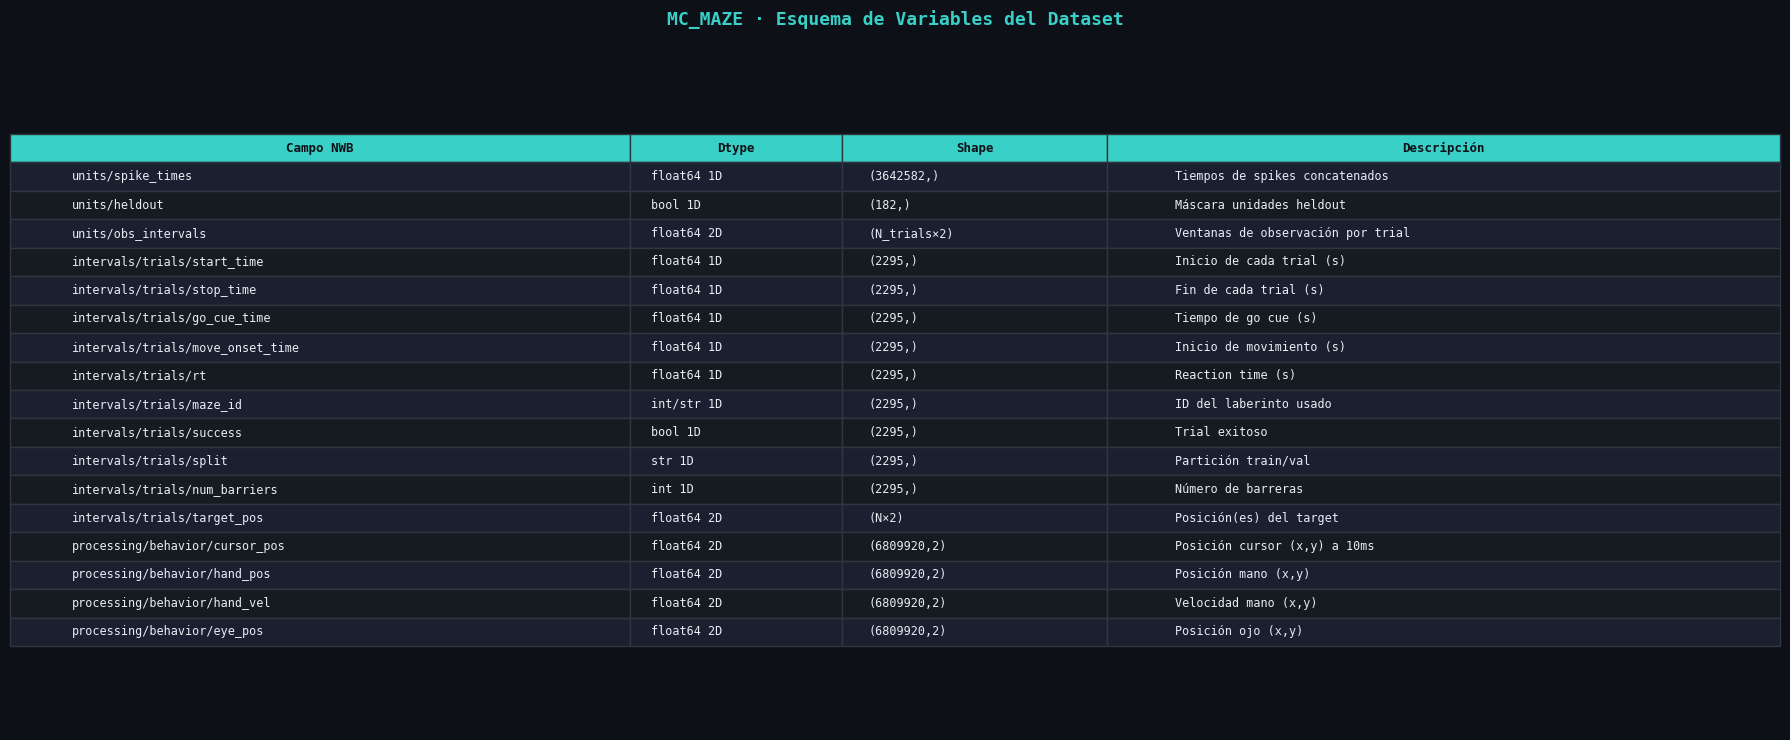

✓ 07_schema_table.png


In [15]:
#@title 7. Resumen
schema = [
    # Señal | Tipo | Shape | Descripción
    ('units/spike_times',              'float64 1D',  f'({n_spikes_train},)',        'Tiempos de spikes concatenados'),
    ('units/heldout',                  'bool 1D',     f'({n_units_train},)',          'Máscara unidades heldout'),
    ('units/obs_intervals',            'float64 2D',  '(N_trials×2)',               'Ventanas de observación por trial'),
    ('intervals/trials/start_time',    'float64 1D',  f'({n_trials_train},)',        'Inicio de cada trial (s)'),
    ('intervals/trials/stop_time',     'float64 1D',  f'({n_trials_train},)',        'Fin de cada trial (s)'),
    ('intervals/trials/go_cue_time',   'float64 1D',  f'({n_trials_train},)',        'Tiempo de go cue (s)'),
    ('intervals/trials/move_onset_time','float64 1D', f'({n_trials_train},)',        'Inicio de movimiento (s)'),
    ('intervals/trials/rt',            'float64 1D',  f'({n_trials_train},)',        'Reaction time (s)'),
    ('intervals/trials/maze_id',       'int/str 1D',  f'({n_trials_train},)',        'ID del laberinto usado'),
    ('intervals/trials/success',       'bool 1D',     f'({n_trials_train},)',        'Trial exitoso'),
    ('intervals/trials/split',         'str 1D',      f'({n_trials_train},)',        'Partición train/val'),
    ('intervals/trials/num_barriers',  'int 1D',      f'({n_trials_train},)',        'Número de barreras'),
    ('intervals/trials/target_pos',    'float64 2D',  '(N×2)',                      'Posición(es) del target'),
    ('processing/behavior/cursor_pos', 'float64 2D',  f'({n_cursor_train},2)',       'Posición cursor (x,y) a 10ms'),
    ('processing/behavior/hand_pos',   'float64 2D',  f'({n_cursor_train},2)',       'Posición mano (x,y)'),
    ('processing/behavior/hand_vel',   'float64 2D',  f'({n_cursor_train},2)',       'Velocidad mano (x,y)'),
    ('processing/behavior/eye_pos',    'float64 2D',  f'({n_cursor_train},2)',       'Posición ojo (x,y)'),
]

fig, ax = plt.subplots(figsize=(18, 7.5))
ax.axis('off')
fig.patch.set_facecolor(C['bg'])

headers = ['Campo NWB', 'Dtype', 'Shape', 'Descripción']
col_data = [[r[0], r[1], r[2], r[3]] for r in schema]

tbl = ax.table(
    cellText=col_data,
    colLabels=headers,
    loc='center',
    cellLoc='left',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.45)

col_widths = [0.35, 0.12, 0.15, 0.38]
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(C['border'])
    if r == 0:
        cell.set_facecolor(C['teal'])
        cell.set_text_props(color=C['bg'], fontweight='bold', fontsize=9)
    elif r % 2 == 0:
        cell.set_facecolor(C['panel'])
        cell.set_text_props(color=C['white'])
    else:
        cell.set_facecolor('#1a2030')
        cell.set_text_props(color=C['white'])
    cell.set_width(col_widths[c])

ax.set_title('MC_MAZE · Esquema de Variables del Dataset',
             color=C['teal'], fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig(f'{OUT}/07_schema_table.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 07_schema_table.png')

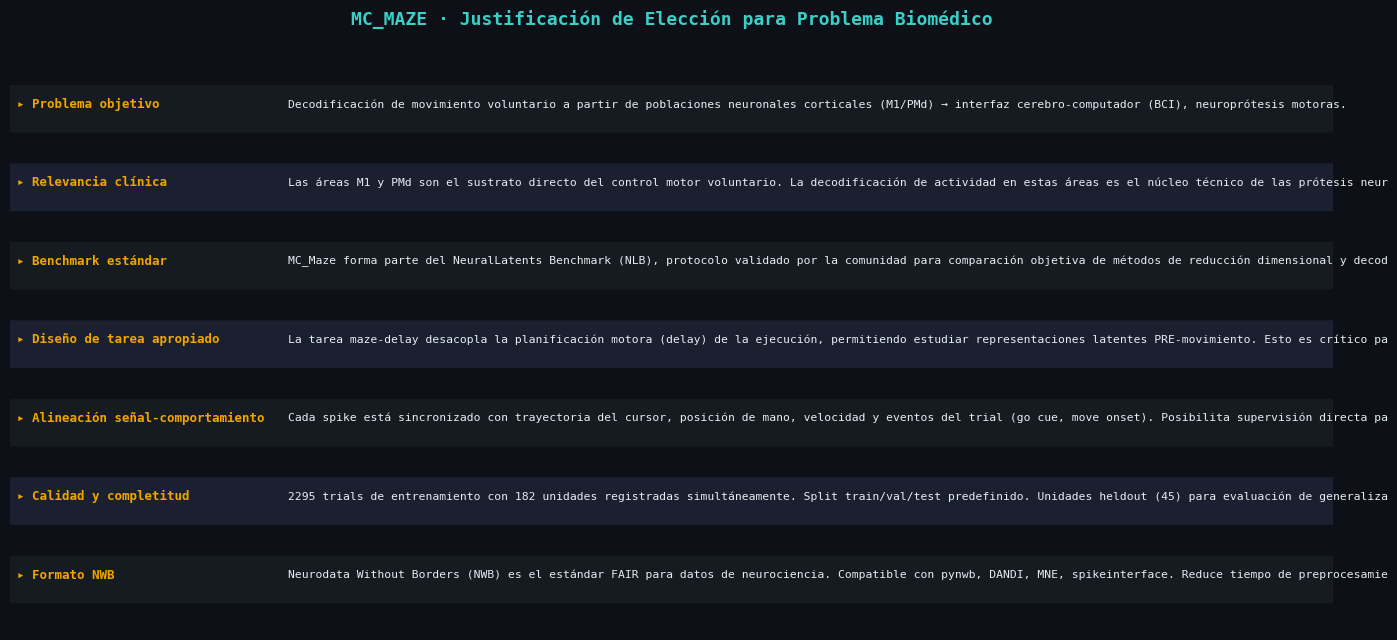

✓ 08_justification.png


In [16]:
#@title 8. Justificación
justification = [
    ('Problema objetivo',
     'Decodificación de movimiento voluntario a partir de poblaciones neuronales corticales '
     '(M1/PMd) → interfaz cerebro-computador (BCI), neuroprótesis motoras.'),

    ('Relevancia clínica',
     'Las áreas M1 y PMd son el sustrato directo del control motor voluntario. '
     'La decodificación de actividad en estas áreas es el núcleo técnico de las prótesis '
     'neurales actuales (BrainGate, Neuralink). El dataset provee condiciones controladas '
     'con variabilidad ecológica (distintos laberintos, barreras).'),

    ('Benchmark estándar',
     'MC_Maze forma parte del NeuralLatents Benchmark (NLB), protocolo validado por la '
     'comunidad para comparación objetiva de métodos de reducción dimensional y decodificación '
     'neuronal. Permite reproducibilidad y comparación con literatura.'),

    ('Diseño de tarea apropiado',
     'La tarea maze-delay desacopla la planificación motora (delay) de la ejecución, '
     'permitiendo estudiar representaciones latentes PRE-movimiento. Esto es crítico para '
     'BCIs predictivas que deben anticipar la intención antes del acto motor.'),

    ('Alineación señal-comportamiento',
     'Cada spike está sincronizado con trayectoria del cursor, posición de mano, velocidad '
     'y eventos del trial (go cue, move onset). Posibilita supervisión directa para '
     'decodificación continua de trayectoria o clasificación de intención.'),

    ('Calidad y completitud',
     f'{n_trials_train} trials de entrenamiento con {n_units_train} unidades registradas '
     f'simultáneamente. Split train/val/test predefinido. Unidades heldout ({n_heldout_train}) '
     'para evaluación de generalización no vista. Formato NWB garantiza interoperabilidad.'),

    ('Formato NWB',
     'Neurodata Without Borders (NWB) es el estándar FAIR para datos de neurociencia. '
     'Compatible con pynwb, DANDI, MNE, spikeinterface. Reduce tiempo de preprocesamiento '
     'y riesgo de errores de alineación temporal.'),
]

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.axis('off')
fig.patch.set_facecolor(C['bg'])

for i, (title, body) in enumerate(justification):
    y = 1 - (i + 0.8) / (len(justification) + 0.5)
    bg_c = C['panel'] if i % 2 == 0 else '#1a2030'
    ax.add_patch(FancyBboxPatch((0.0, y - 0.045), 1.0, 0.075,
                                boxstyle='round,pad=0.003',
                                facecolor=bg_c, edgecolor='none',
                                transform=ax.transAxes, zorder=0))
    ax.text(0.005, y, f'▸ {title}', transform=ax.transAxes,
            color=C['amber'], fontsize=9, fontweight='bold', va='center')
    ax.text(0.21, y, body[:160], transform=ax.transAxes,
            color=C['white'], fontsize=8.2, va='center', wrap=True)

ax.set_title('MC_MAZE · Justificación de Elección para Problema Biomédico',
             color=C['teal'], fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{OUT}/08_justification.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 08_justification.png')

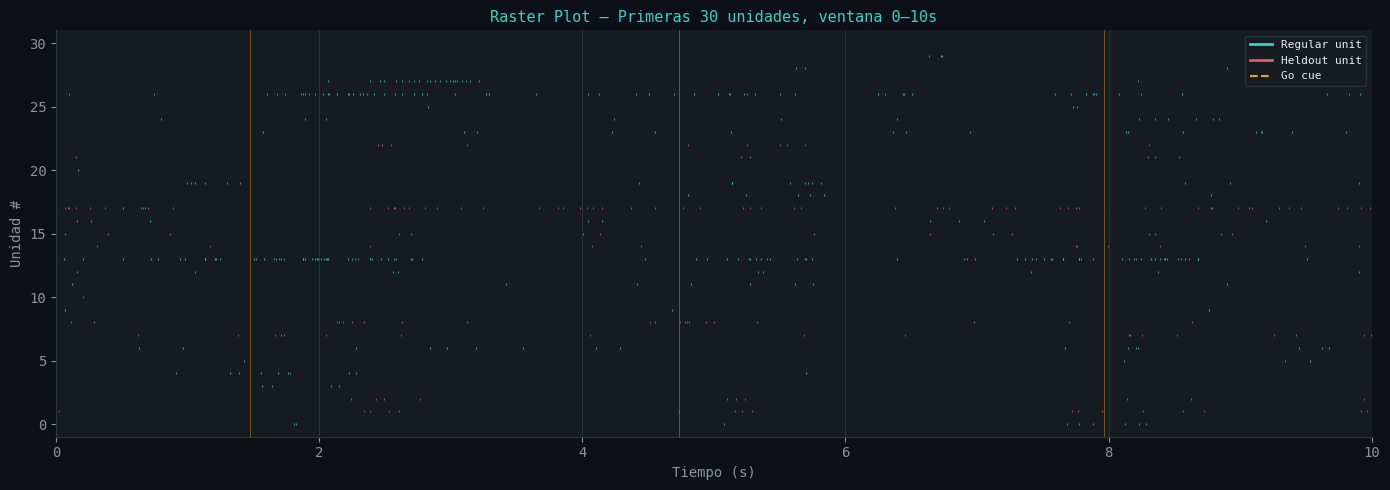

✓ 09_raster_plot.png


In [17]:
#@title 9. Ejemplo
# Tomar las primeras 5 unidades, ventana 0-10s
t_win = (0, 10)
n_units_show = min(30, n_units_train)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['panel'])

prev_idx = 0
unit_ids_shown = 0
for u in range(n_units_train):
    end_idx = int(spike_idx[u])
    spks = spike_times[prev_idx:end_idx]
    prev_idx = end_idx
    mask = (spks >= t_win[0]) & (spks <= t_win[1])
    spks_win = spks[mask]
    if len(spks_win) == 0: continue
    col = C['teal'] if not heldout[u] else C['red']
    ax.scatter(spks_win, np.full_like(spks_win, unit_ids_shown),
               s=1.5, marker='|', color=col, alpha=0.7, linewidths=0.8)
    unit_ids_shown += 1
    if unit_ids_shown >= n_units_show: break

# Go cue lines
gc = go_cue[(go_cue >= t_win[0]) & (go_cue <= t_win[1])]
for t in gc[:15]:
    ax.axvline(t, color=C['amber'], lw=0.6, alpha=0.5)

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0], [0], color=C['teal'],  lw=2, label='Regular unit'),
    Line2D([0], [0], color=C['red'],   lw=2, label='Heldout unit'),
    Line2D([0], [0], color=C['amber'], lw=1.5, ls='--', label='Go cue'),
]
ax.legend(handles=legend_els, fontsize=8, loc='upper right',
          facecolor=C['panel'], edgecolor=C['border'])
ax.set_xlabel('Tiempo (s)', color=C['gray'])
ax.set_ylabel('Unidad #', color=C['gray'])
ax.set_title(f'Raster Plot — Primeras {n_units_show} unidades, ventana 0–10s',
             color=C['teal'], fontsize=11)
ax.set_xlim(t_win); ax.set_ylim(-1, n_units_show + 1)
ax.grid(axis='x', zorder=0)
plt.tight_layout()
plt.savefig(f'{OUT}/09_raster_plot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('✓ 09_raster_plot.png')



In [18]:

#@title RESUMEN FINAL EN CONSOLA
print('\n' + '='*65)
print('  MC_MAZE STANDARD — RESUMEN EJECUTIVO')
print('='*65)
print(f'  Dataset     : MC_Maze (NeuralLatents Benchmark)')
print(f'  Acceso      : https://dandiarchive.org/dandiset/000128')
print(f'  Formato     : NWB 2.4.0 (HDF5)')
print(f'  Sujeto      : Jenkins (Macaca mulatta, macho)')
print(f'  Áreas       : M1 (corteza motora primaria) + PMd (premotor dorsal)')
print(f'  Electrodos  : {n_elec}')
print(f'  Unidades    : {n_units_train} (train) | {n_units_test} (test)')
print(f'  Heldout     : {n_heldout_train} (train) | {n_heldout_test} (test)')
print(f'  Trials      : {n_trials_train} (train) | {n_trials_test} (test)')
print(f'  Spikes      : {n_spikes_train:,} (train) | {n_spikes_test:,} (test)')
print(f'  Señales     : cursor_pos, hand_pos, hand_vel, eye_pos @ 100Hz')
print(f'  Laberintos  : {len(np.unique(maze_ids_s))} variantes')
print(f'  Tasa éxito  : {np.mean([str(s) in ("1","True","b\"1\"") for s in success_s])*100:.1f}%')
print('='*65)
print(f'\n  Outputs guardados en: {OUT}/')
print('  01_metadata_table.png')
print('  02_size_structure.png')
print('  03_class_distribution.png')
print('  04_trial_timing.png')
print('  05_behavior_signals.png')
print('  06_neural_activity.png')
print('  07_schema_table.png')
print('  08_justification.png')
print('  09_raster_plot.png')

f_train.close()
f_test.close()


  MC_MAZE STANDARD — RESUMEN EJECUTIVO
  Dataset     : MC_Maze (NeuralLatents Benchmark)
  Acceso      : https://dandiarchive.org/dandiset/000128
  Formato     : NWB 2.4.0 (HDF5)
  Sujeto      : Jenkins (Macaca mulatta, macho)
  Áreas       : M1 (corteza motora primaria) + PMd (premotor dorsal)
  Electrodos  : 192
  Unidades    : 182 (train) | 137 (test)
  Heldout     : 45 (train) | 0 (test)
  Trials      : 2295 (train) | 574 (test)
  Spikes      : 3,642,582 (train) | 230,348 (test)
  Señales     : cursor_pos, hand_pos, hand_vel, eye_pos @ 100Hz
  Laberintos  : 36 variantes
  Tasa éxito  : 100.0%

  Outputs guardados en: /content/eda_outputs/
  01_metadata_table.png
  02_size_structure.png
  03_class_distribution.png
  04_trial_timing.png
  05_behavior_signals.png
  06_neural_activity.png
  07_schema_table.png
  08_justification.png
  09_raster_plot.png


### 10. Extracción de Características y Etiquetas del NWB

Aquí definimos una función para extraer las secuencias de actividad neuronal (tasas de disparo binned) y las etiquetas de clase angular para cada trial. Esta función procesa los datos brutos del formato NWB y los prepara para la entrada del modelo LSTM.

In [19]:
def extract_features_and_labels(nwb_file, timesteps_input, bin_size, window_start_offset_s, window_end_offset_s, num_classes):
    spike_times = nwb_file['units/spike_times'][()]
    spike_idx = nwb_file['units/spike_times_index'][()]
    move_onset = nwb_file['intervals/trials/move_onset_time'][()]

    n_units = len(nwb_file['units/id'][()])
    n_trials = len(move_onset)

    # Determine the actual time window in seconds
    window_duration_s = window_end_offset_s - window_start_offset_s
    if window_duration_s <= 0:
        raise ValueError("Window duration must be positive.")

    # Calculate the number of bins per window based on bin_size
    # Recalculate timesteps_input to ensure it matches the actual bins created
    # if the desired window_duration_s is not perfectly divisible by bin_size
    actual_timesteps_input = int(round(window_duration_s / bin_size))
    if actual_timesteps_input != timesteps_input:
        print(f"Warning: `timesteps_input` was {timesteps_input}, but for a window of "
              f"{window_duration_s:.3f}s with bin_size={bin_size:.3f}s, "
              f"it's adjusted to {actual_timesteps_input} bins.")
        timesteps_input = actual_timesteps_input

    X_features = np.zeros((n_trials, timesteps_input, n_units), dtype=np.float32)
    y_labels = np.zeros(n_trials, dtype=np.int32)

    # Check for behavioral data presence
    has_behavior_data = False
    if 'processing' in nwb_file and \
       'behavior' in nwb_file['processing'] and \
       'cursor_pos' in nwb_file['processing/behavior'] and \
       'timestamps' in nwb_file['processing/behavior']['cursor_pos'] and \
       'data' in nwb_file['processing/behavior']['cursor_pos']:
        cursor_ts = nwb_file['processing/behavior/cursor_pos/timestamps'][()]
        cursor_pos = nwb_file['processing/behavior/cursor_pos/data'][()]
        has_behavior_data = True
    else:
        print(f"Warning: Behavioral data (cursor_pos) not found in {nwb_file.filename}. No behavioral labels will be extracted.")

    # Pre-calculate bin edges for angular classes (from cell mptR75r4UK_8)
    bin_edges_angular = np.array([-180, -157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5, 180])

    prev_spike_idx = 0
    all_unit_spikes = []
    for i in range(len(spike_idx)):
        current_spike_idx = spike_idx[i]
        all_unit_spikes.append(spike_times[prev_spike_idx:current_spike_idx])
        prev_spike_idx = current_spike_idx


    for trial_idx in range(n_trials):
        # ---------------------------------------------------------
        # Extract features (binned firing rates)
        # ---------------------------------------------------------
        trial_move_onset = move_onset[trial_idx]
        window_start_time = trial_move_onset + window_start_offset_s
        window_end_time = trial_move_onset + window_end_offset_s

        # Create time bins for this trial's window
        bins = np.linspace(window_start_time, window_end_time, timesteps_input + 1)

        for unit_id in range(n_units):
            unit_spike_times = all_unit_spikes[unit_id]
            # Filter spikes within the trial's window
            spikes_in_window = unit_spike_times[(unit_spike_times >= window_start_time) & (unit_spike_times < window_end_time)]

            # Bin spikes
            if len(spikes_in_window) > 0:
                counts, _ = np.histogram(spikes_in_window, bins=bins)
                # Convert counts to firing rate (spikes/second)
                X_features[trial_idx, :, unit_id] = counts / bin_size

        # ---------------------------------------------------------
        # Extract labels (angular class)
        # ---------------------------------------------------------
        if has_behavior_data:
            # Logic from cell mptR75r4UK_8
            WINDOW_SAMPLES_CURSOR = int(0.5 / (cursor_ts[1] - cursor_ts[0])) # 500ms at cursor sampling rate
            idx_start_cursor = np.searchsorted(cursor_ts, trial_move_onset)
            idx_end_cursor = idx_start_cursor + WINDOW_SAMPLES_CURSOR

            current_angle_deg = np.nan # Default if trial is invalid
            if idx_end_cursor < len(cursor_pos):
                hand_start = cursor_pos[idx_start_cursor]
                hand_end   = cursor_pos[idx_end_cursor]

                dx = hand_end[0] - hand_start[0]
                dy = hand_end[1] - hand_start[1]
                current_angle_deg = np.degrees(np.arctan2(dy, dx))

            if not np.isnan(current_angle_deg):
                angles_clipped = np.clip(current_angle_deg, -179.99, 179.99)
                bin_idx_angular = np.digitize(angles_clipped, bin_edges_angular[1:-1]) % num_classes
                y_labels[trial_idx] = bin_idx_angular
            else:
                # Assign -1 to indicate invalid, will filter later
                y_labels[trial_idx] = -1
        else:
            # If no behavioral data for this NWB file, set label to -1
            y_labels[trial_idx] = -1

    # Filter out invalid trials if any (-1 labels) - this will filter all if has_behavior_data is False
    valid_trials_mask = (y_labels != -1)
    X_features = X_features[valid_trials_mask]
    y_labels = y_labels[valid_trials_mask]

    return X_features, y_labels

### 11. Preparación Final de Datos para el Modelo LSTM

Aquí aplicamos la función de extracción a los archivos `f_train` y `f_test`. Luego, dividimos el conjunto de entrenamiento en subconjuntos de entrenamiento y validación utilizando el `split` definido en el NWB, y preparamos el conjunto de prueba para la evaluación final del modelo.

In [20]:
import h5py # Import h5py
import numpy as np # Import numpy

# Definir parámetros para la extracción de características
TIMESTEPS_INPUT = 10  # Número de bins de tiempo para la secuencia LSTM
BIN_SIZE = 0.05       # Tamaño de cada bin en segundos (50 ms)

# Ventana de tiempo para la extracción de características neuronales (relativa a move_onset)
# Por ejemplo, de 200ms antes de move_onset a 300ms después, para un total de 500ms.
WINDOW_START_OFFSET_S = -0.2
WINDOW_END_OFFSET_S = 0.3

# Número de clases angulares (definido en el análisis previo)
NUM_ANGULAR_CLASSES = 8

# --- Re-abrir los archivos NWB ---
# Esto asegura que los manejadores de archivo f_train y f_test estén disponibles
# para la extracción de características, ya que podrían haberse cerrado antes.
# Se corrige la ruta para usar el directorio correcto '/content/000128/'.
TRAIN_PATH = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'
TEST_PATH  = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb'
f_train = h5py.File(TRAIN_PATH, 'r')
f_test  = h5py.File(TEST_PATH,  'r')
# ----------------------------------

# Extraer características y etiquetas del archivo de entrenamiento (que incluye train y val originales)
print("Procesando datos de entrenamiento y validación originales...")
X_raw, y_raw = extract_features_and_labels(
    f_train, TIMESTEPS_INPUT, BIN_SIZE, WINDOW_START_OFFSET_S, WINDOW_END_OFFSET_S, NUM_ANGULAR_CLASSES
)

# Dividir los datos en 70% entrenamiento, 15% validación, 15% prueba
# Primero, separamos el 70% para entrenamiento y el 30% restante para validación + prueba.
X_train_final, X_temp, y_train, y_temp = train_test_split(X_raw, y_raw, test_size=0.30, random_state=42, stratify=y_raw)

# Luego, dividimos el 30% restante en partes iguales para validación y prueba (15% cada uno del total original).
X_val_final, X_test_internal, y_val, y_test_internal = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)


# Extraer características y etiquetas del archivo de prueba NWB original (sin etiquetas de comportamiento)
# Esto se mantiene separado ya que el objetivo es evaluar el modelo en un 'test' real si estuviera disponible
print("Procesando datos del archivo de prueba NWB original (sin etiquetas de comportamiento)...")
X_test_nwb_original, y_test_nwb_original = extract_features_and_labels(
    f_test, TIMESTEPS_INPUT, BIN_SIZE, WINDOW_START_OFFSET_S, WINDOW_END_OFFSET_S, NUM_ANGULAR_CLASSES
)

# Check if y_test_nwb_original is empty due to lack of behavioral data
if len(y_test_nwb_original) == 0:
    print("Warning: `y_test_nwb_original` es vacío. El archivo NWB de prueba no contiene etiquetas de comportamiento para clasificación.")
    X_test_nwb_original = np.array([])


print("Datos preparados con división 70/15/15:")
print(f"X_train_final shape: {X_train_final.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val_final shape: {X_val_final.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test_internal shape: {X_test_internal.shape}")
print(f"y_test_internal shape: {y_test_internal.shape}")

if X_test_nwb_original.size > 0:
    print(f"X_test_nwb_original shape: {X_test_nwb_original.shape}")
    print(f"y_test_nwb_original shape: {y_test_nwb_original.shape}")
else:
    print("X_test_nwb_original y y_test_nwb_original están vacíos debido a la falta de datos de comportamiento en el archivo de prueba.")

# Cerrar los archivos NWB, ya no son necesarios después de la extracción
f_train.close()
f_test.close()

Procesando datos de entrenamiento y validación originales...
Procesando datos del archivo de prueba NWB original (sin etiquetas de comportamiento)...
Datos preparados con división 70/15/15:
X_train_final shape: (1606, 10, 182)
y_train shape: (1606,)
X_val_final shape: (344, 10, 182)
y_val shape: (344,)
X_test_internal shape: (345, 10, 182)
y_test_internal shape: (345,)
X_test_nwb_original y y_test_nwb_original están vacíos debido a la falta de datos de comportamiento en el archivo de prueba.


In [21]:
#@title Definición de hiperparámetros de regularización (ajustados)
# Se ajustan los valores según lo acordado para combatir el sobreajuste
DROPOUT1_RATE = 0.5  # Aumentado de 0.4
DROPOUT2_RATE = 0.5  # Aumentado de 0.4
L2_REGULARIZATION_STRENGTH = 0.003 # Aumentado de 0.002

# Otros hiperparámetros del modelo
LSTM1_UNITS = 96
LSTM2_UNITS = 64
LEARNING_RATE = 0.001
EPOCHS = 200
BATCH_SIZE = 64
PATIENCE_ES = 20 # Paciencia para Early Stopping
PATIENCE_LR = 7 # Paciencia para ReduceLROnPlateau

# Obtener el número de características de los datos preparados
features_input = X_train_final.shape[2]

print(f"Hiperparámetros de regularización actualizados:")
print(f"  DROPOUT1_RATE: {DROPOUT1_RATE}")
print(f"  DROPOUT2_RATE: {DROPOUT2_RATE}")
print(f"  L2_REGULARIZATION_STRENGTH: {L2_REGULARIZATION_STRENGTH}")
print(f"  LSTM1_UNITS: {LSTM1_UNITS}")
print(f"  LSTM2_UNITS: {LSTM2_UNITS}")
print(f"  LEARNING_RATE: {LEARNING_RATE}")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"  PATIENCE_ES (Early Stopping): {PATIENCE_ES}")
print(f"  PATIENCE_LR (ReduceLROnPlateau): {PATIENCE_LR}")
print(f"  Número de características (features_input): {features_input}")

Hiperparámetros de regularización actualizados:
  DROPOUT1_RATE: 0.5
  DROPOUT2_RATE: 0.5
  L2_REGULARIZATION_STRENGTH: 0.003
  LSTM1_UNITS: 96
  LSTM2_UNITS: 64
  LEARNING_RATE: 0.001
  BATCH_SIZE: 64
  PATIENCE_ES (Early Stopping): 20
  PATIENCE_LR (ReduceLROnPlateau): 7
  Número de características (features_input): 182


In [22]:
import os

# Ruta base donde se esperan los archivos NWB
base_nwb_dir = '/content/000128/sub-Jenkins/'

print(f"Contenido del directorio '{base_nwb_dir}':")
if os.path.exists(base_nwb_dir):
    for item in os.listdir(base_nwb_dir):
        print(f"- {item}")
else:
    print(f"El directorio '{base_nwb_dir}' no existe.")

# Verificar la existencia de los archivos específicos
train_file_exists = os.path.exists(TRAIN_PATH)
test_file_exists = os.path.exists(TEST_PATH)

print(f"\nVerificando archivos específicos:")
print(f"- Archivo de entrenamiento '{TRAIN_PATH}': {'Existe' if train_file_exists else 'NO EXISTE'}")
print(f"- Archivo de prueba '{TEST_PATH}': {'Existe' if test_file_exists else 'NO EXISTE'}")

Contenido del directorio '/content/000128/sub-Jenkins/':
- sub-Jenkins_ses-full_desc-test_ecephys.nwb
- sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb

Verificando archivos específicos:
- Archivo de entrenamiento '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb': Existe
- Archivo de prueba '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb': Existe


### Verificación de Contenido del Archivo de Prueba NWB




### 13. Reentrenamiento con Solo Dos Bloques de Datos

--- CONFIGURACIÓN DE PESOS MIGRATORIOS CONTRA DESBALANCE (FILTRADO) ---
Clase 0 (original: 0): Peso de penalización asignado = 0.91
Clase 1 (original: 1): Peso de penalización asignado = 0.86
Clase 2 (original: 2): Peso de penalización asignado = 13.74
Clase 3 (original: 3): Peso de penalización asignado = 0.65
Clase 4 (original: 5): Peso de penalización asignado = 0.77
Clase 5 (original: 6): Peso de penalización asignado = 1.21
------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 96)         │       107,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,742 (581.02 KB)

 Trainable params: 148,742 (581.02 KB)

 Non-trainable params: 0 (0.00 B)


--- ENTRENANDO MODELO CON CLASES FILTRADAS ---
Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.2506 - loss: 2.8079 - val_accuracy: 0.6340 - val_loss: 2.4674 - learning_rate: 0.0010
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6063 - loss: 2.3146 - val_accuracy: 0.8038 - val_loss: 1.9676 - learning_rate: 0.0010
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7680 - loss: 1.7761 - val_accuracy: 0.8302 - val_loss: 1.4490 - learning_rate: 0.0010
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8399 - loss: 1.3112 - val_accuracy: 0.8717 - val_loss: 1.2006 - learning_rate: 0.0010
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9022 - loss: 1.0651 - val_accuracy: 0.8943 - val_loss: 1.0354 - learning_rate: 0.0010
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9386 - loss: 0.9107 - val_accuracy: 0.8755 - val_loss: 0.9737 - learning_rate: 0.0010
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1

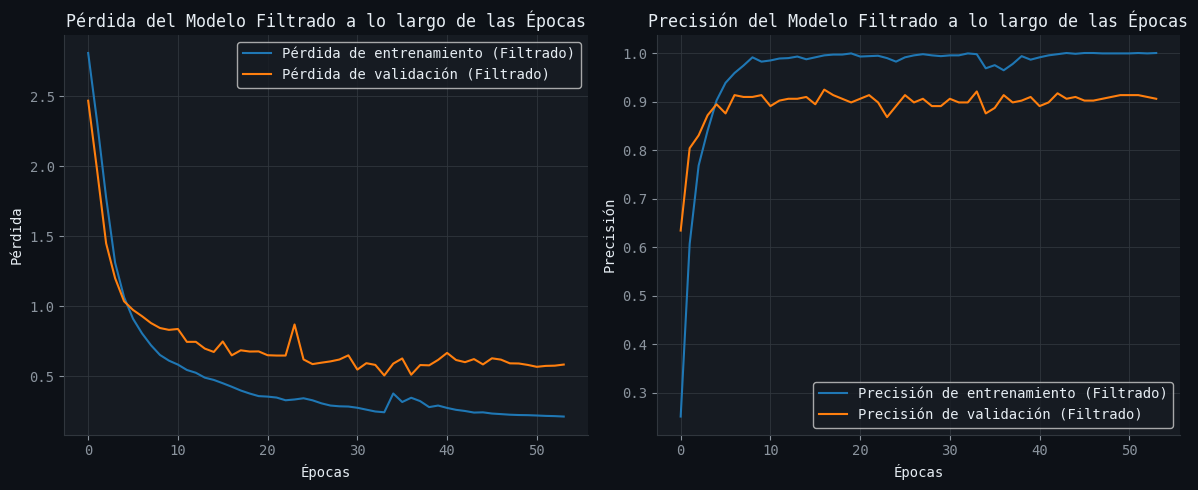

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import pandas as pd

# Identificar las clases a excluir (Clase 7 y Clase 4)
classes_to_exclude = [7, 4]

# Crear máscaras para filtrar los datos de entrenamiento y validación
mask_train_filtered = ~np.isin(y_train, classes_to_exclude)
mask_val_filtered = ~np.isin(y_val, classes_to_exclude)
mask_test_internal_filtered = ~np.isin(y_test_internal, classes_to_exclude)

X_train_filtered = X_train_final[mask_train_filtered]
y_train_filtered = y_train[mask_train_filtered]

X_val_filtered = X_val_final[mask_val_filtered]
y_val_filtered = y_val[mask_val_filtered]

X_test_internal_filtered = X_test_internal[mask_test_internal_filtered]
y_test_internal_filtered = y_test_internal[mask_test_internal_filtered]

# Actualizar num_classes para reflejar las clases restantes (8 - 2 = 6)
# Necesitamos mapear las etiquetas existentes a un rango de 0 a 5
# para que to_categorical funcione correctamente.
# Primero, obtengamos las clases únicas y su nuevo mapeo
unique_classes_filtered = np.unique(y_train_filtered)
class_mapping = {old_class: new_class for new_class, old_class in enumerate(unique_classes_filtered)}

y_train_mapped = np.array([class_mapping[c] for c in y_train_filtered])
y_val_mapped = np.array([class_mapping[c] for c in y_val_filtered])
y_test_internal_mapped = np.array([class_mapping[c] for c in y_test_internal_filtered])

num_classes_filtered = len(unique_classes_filtered)

# Convertir etiquetas a formato categórico con el nuevo número de clases
y_train_categorical_filtered = tf.keras.utils.to_categorical(y_train_mapped, num_classes=num_classes_filtered)
y_val_categorical_filtered = tf.keras.utils.to_categorical(y_val_mapped, num_classes=num_classes_filtered)
y_test_internal_categorical_filtered = tf.keras.utils.to_categorical(y_test_internal_mapped, num_classes=num_classes_filtered)

# Recalcular pesos de clase para los datos filtrados
pesos_clases_filtered = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_mapped),
    y=y_train_mapped
)
dict_pesos_clases_filtered = dict(enumerate(pesos_clases_filtered))

print("--- CONFIGURACIÓN DE PESOS MIGRATORIOS CONTRA DESBALANCE (FILTRADO) ---")
for clase, peso in dict_pesos_clases_filtered.items():
    print(f"Clase {clase} (original: {unique_classes_filtered[clase]}): Peso de penalización asignado = {peso:.2f}")
print("-" * 60)

# Re-definir el modelo con los hiperparámetros ajustados previamente
model_filtered = Sequential([
    LSTM(LSTM1_UNITS, return_sequences=True, input_shape=(TIMESTEPS_INPUT, features_input), activation='tanh',
         kernel_regularizer=regularizers.l2(L2_REGULARIZATION_STRENGTH)),
    Dropout(DROPOUT1_RATE),

    LSTM(LSTM2_UNITS, return_sequences=False, activation='tanh',
         kernel_regularizer=regularizers.l2(L2_REGULARIZATION_STRENGTH)),
    Dropout(DROPOUT2_RATE),

    Dense(num_classes_filtered, activation='softmax') # Usar num_classes_filtered
])

# Compilar el modelo
model_filtered.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_filtered.summary()

# Configurar callbacks con los mismos valores de paciencia
early_stopping_filtered = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_filtered = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR,
    min_lr=1e-7,
    verbose=1
)

print("\n--- ENTRENANDO MODELO CON CLASES FILTRADAS ---")
history_filtered = model_filtered.fit(
    X_train_filtered, y_train_categorical_filtered,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_filtered, y_val_categorical_filtered),
    class_weight=dict_pesos_clases_filtered,
    callbacks=[early_stopping_filtered, reduce_lr_filtered],
    verbose=1
)

# Evaluación exhaustiva de métricas por clase en el nuevo conjunto de prueba interno
print("\n" + "="*60)
print("INFORMES DE DESEMPEÑO DEL CLASIFICADOR RECURRENTE (TEST INTERNO - Filtrado)")
print("="*60)

y_pred_internal_prob = model_filtered.predict(X_test_internal_filtered)
y_pred_internal = np.argmax(y_pred_internal_prob, axis=1)

# Usar el mapeo inverso para el reporte si las etiquetas originales son importantes,
# o usar las etiquetas mapeadas directamente.
# Para el reporte, es más fácil usar las etiquetas mapeadas y luego indicar las originales.

print(classification_report(
    y_test_internal_mapped, y_pred_internal,
    target_names=[f"Clase_Mapeada_{i} (Original_{unique_classes_filtered[i]})" for i in range(num_classes_filtered)]
))

print("MATRIZ DE CONFUSIÓN (TEST INTERNO - Etiquetas Mapeadas):")
print(confusion_matrix(y_test_internal_mapped, y_pred_internal))

# Si el archivo NWB de prueba original existe, todavía se puede procesar su X_features
# pero no se puede evaluar la clasificación angular si no tiene etiquetas de comportamiento.
if X_test_nwb_original.size > 0:
    print("\n" + "="*60)
    print("Nota: El archivo NWB de prueba original se procesó, pero no contiene etiquetas de comportamiento.")
    print("Por lo tanto, no se puede evaluar el rendimiento de clasificación en este conjunto.")
    print("X_test_nwb_original shape: {X_test_nwb_original.shape}")
    print("="*60)


# Plotting the training history for the filtered model
hist_df_filtered = pd.DataFrame(history_filtered.history)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_df_filtered.index, hist_df_filtered['loss'], label='Pérdida de entrenamiento (Filtrado)')
plt.plot(hist_df_filtered.index, hist_df_filtered['val_loss'], label='Pérdida de validación (Filtrado)')
plt.title('Pérdida del Modelo Filtrado a lo largo de las Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_df_filtered.index, hist_df_filtered['accuracy'], label='Precisión de entrenamiento (Filtrado)')
plt.plot(hist_df_filtered.index, hist_df_filtered['val_accuracy'], label='Precisión de validación (Filtrado)')
plt.title('Precisión del Modelo Filtrado a lo largo de las Épocas')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Pesos de clase utilizados:
Clase mapeada 0 (original 0): peso = 0.912
Clase mapeada 1 (original 1): peso = 0.863
Clase mapeada 2 (original 2): peso = 13.744
Clase mapeada 3 (original 3): peso = 0.648
Clase mapeada 4 (original 5): peso = 0.766
Clase mapeada 5 (original 6): peso = 1.213


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 96)         │       107,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,742 (581.02 KB)

 Trainable params: 148,742 (581.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.2708 - loss: 2.8279 - val_accuracy: 0.5811 - val_loss: 2.5202 - learning_rate: 0.0010
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5635 - loss: 2.3437 - val_accuracy: 0.7509 - val_loss: 2.0184 - learning_rate: 0.0010
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7437 - loss: 1.8228 - val_accuracy: 0.8604 - val_loss: 1.4409 - learning_rate: 0.0010
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8222 - loss: 1.3252 - val_accuracy: 0.8792 - val_loss: 1.1555 - learning_rate: 0.0010
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8925 - loss: 1.0537 - val_accuracy: 0.8717 - val_loss: 1.0406 - learning_rate: 0.0010
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9410 - loss: 0.8955 - val_accuracy: 0.8792 - val_loss: 0.9622 - learning_rate: 0.0010
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9596 - loss: 0.7824 - 

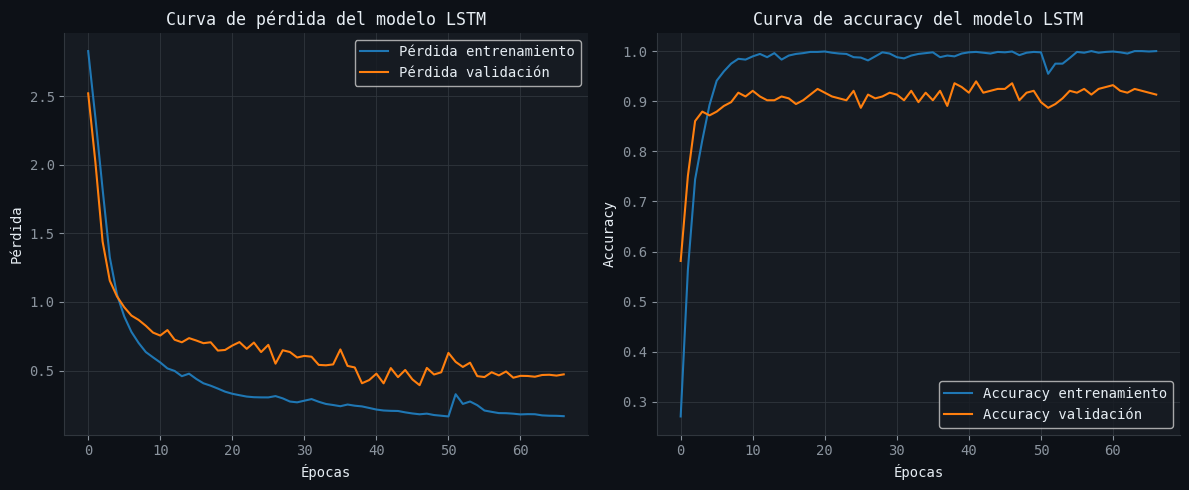

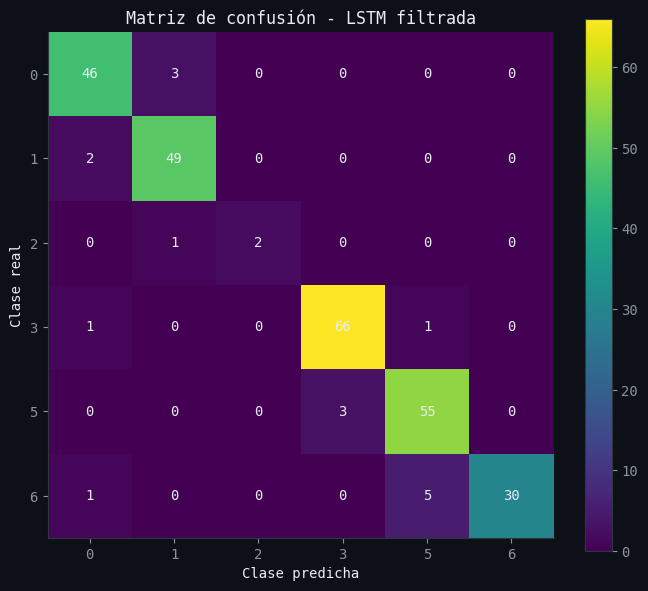

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd


# Se eliminan las clases 4 (±180°) y 7 (-45°)
classes_to_exclude = [4, 7]

mask_train_filtered = ~np.isin(y_train, classes_to_exclude)
mask_val_filtered = ~np.isin(y_val, classes_to_exclude)
mask_test_filtered = ~np.isin(y_test_internal, classes_to_exclude)

X_train_filtered = X_train_final[mask_train_filtered]
y_train_filtered = y_train[mask_train_filtered]

X_val_filtered = X_val_final[mask_val_filtered]
y_val_filtered = y_val[mask_val_filtered]

X_test_filtered = X_test_internal[mask_test_filtered]
y_test_filtered = y_test_internal[mask_test_filtered]


unique_classes_filtered = np.unique(y_train_filtered)
class_mapping = {
    old_class: new_class
    for new_class, old_class in enumerate(unique_classes_filtered)
}

inverse_mapping = {
    new_class: old_class
    for old_class, new_class in class_mapping.items()
}

y_train_mapped = np.array([class_mapping[c] for c in y_train_filtered])
y_val_mapped = np.array([class_mapping[c] for c in y_val_filtered])
y_test_mapped = np.array([class_mapping[c] for c in y_test_filtered])

num_classes_filtered = len(unique_classes_filtered)

y_train_cat = tf.keras.utils.to_categorical(
    y_train_mapped,
    num_classes=num_classes_filtered
)

y_val_cat = tf.keras.utils.to_categorical(
    y_val_mapped,
    num_classes=num_classes_filtered
)

y_test_cat = tf.keras.utils.to_categorical(
    y_test_mapped,
    num_classes=num_classes_filtered
)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_mapped),
    y=y_train_mapped
)

class_weight_dict = dict(enumerate(class_weights))

print("Pesos de clase utilizados:")
for clase_mapeada, peso in class_weight_dict.items():
    clase_original = inverse_mapping[clase_mapeada]
    print(
        f"Clase mapeada {clase_mapeada} "
        f"(original {clase_original}): peso = {peso:.3f}"
    )


TIMESTEPS_INPUT = X_train_filtered.shape[1]
features_input = X_train_filtered.shape[2]

LSTM1_UNITS = 96
LSTM2_UNITS = 64
DROPOUT_RATE = 0.5
L2_REGULARIZATION = 0.003
LEARNING_RATE = 0.001
EPOCHS = 200
BATCH_SIZE = 64
PATIENCE_ES = 20
PATIENCE_LR = 7

model = Sequential([
    LSTM(
        LSTM1_UNITS,
        return_sequences=True,
        input_shape=(TIMESTEPS_INPUT, features_input),
        activation="tanh",
        kernel_regularizer=regularizers.l2(L2_REGULARIZATION)
    ),
    Dropout(DROPOUT_RATE),

    LSTM(
        LSTM2_UNITS,
        return_sequences=False,
        activation="tanh",
        kernel_regularizer=regularizers.l2(L2_REGULARIZATION)
    ),
    Dropout(DROPOUT_RATE),

    Dense(num_classes_filtered, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE_ES,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=PATIENCE_LR,
    min_lr=1e-7,
    verbose=1
)


history = model.fit(
    X_train_filtered,
    y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_filtered, y_val_cat),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


y_pred_prob = model.predict(X_test_filtered)
y_pred = np.argmax(y_pred_prob, axis=1)

target_names = [
    f"Clase {i} original {inverse_mapping[i]}"
    for i in range(num_classes_filtered)
]

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test_mapped,
        y_pred,
        target_names=target_names
    )
)

cm = confusion_matrix(y_test_mapped, y_pred)

print("\nMatriz de confusión:")
print(cm)

hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_df.index, hist_df["loss"], label="Pérdida entrenamiento")
plt.plot(hist_df.index, hist_df["val_loss"], label="Pérdida validación")
plt.title("Curva de pérdida del modelo LSTM")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_df.index, hist_df["accuracy"], label="Accuracy entrenamiento")
plt.plot(hist_df.index, hist_df["val_accuracy"], label="Accuracy validación")
plt.title("Curva de accuracy del modelo LSTM")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Matriz de confusión visual
plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Matriz de confusión - LSTM filtrada")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.colorbar()

plt.xticks(
    ticks=np.arange(num_classes_filtered),
    labels=[str(inverse_mapping[i]) for i in range(num_classes_filtered)]
)

plt.yticks(
    ticks=np.arange(num_classes_filtered),
    labels=[str(inverse_mapping[i]) for i in range(num_classes_filtered)]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Clases conservadas: [0 1 2 3 5 6]
Train: (1237, 10, 182)
Val: (265, 10, 182)
Test: (265, 10, 182)
Train aplanado: (1237, 1820)
Test aplanado: (265, 1820)

--- MÉTRICAS VALIDACIÓN SVM ---
Accuracy:  0.9283
Precision: 0.7801
Recall:    0.7766
F1 Macro:  0.7756

--- MÉTRICAS TEST SVM ---
Accuracy:  0.9283
Precision: 0.7816
Recall:    0.7786
F1 Macro:  0.7764

--- REPORTE DE CLASIFICACIÓN SVM - TEST ---
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        49
           1       0.82      1.00      0.90        51
           2       0.00      0.00      0.00         3
           3       0.93      1.00      0.96        68
           5       0.96      0.93      0.95        58
           6       0.97      0.94      0.96        36

    accuracy                           0.93       265
   macro avg       0.78      0.78      0.78       265
weighted avg       0.93      0.93      0.92       265



,Modelo,Kernel,C,Gamma,Class weight,Accuracy Test,Precision Macro Test,Recall Macro Test,F1 Macro Test
0,SVM Baseline,RBF,1.0,scale,balanced,0.9283,0.7816,0.7786,0.7764


<Figure size 700x600 with 0 Axes>

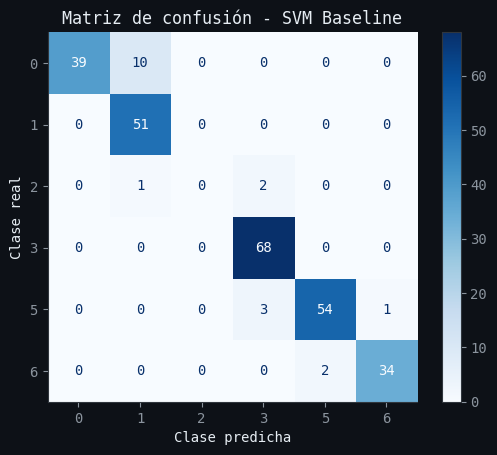

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,SVM Baseline,0.9283,0.7816,0.7786,0.7764
1,LSTM,0.9400,0.9500,0.8900,0.9100


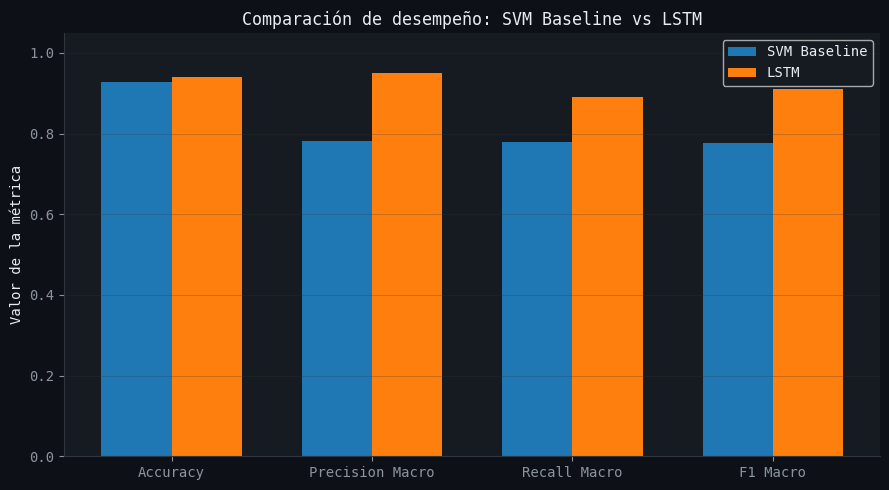

In [25]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


classes_to_exclude = [4, 7]

mask_train = ~np.isin(y_train, classes_to_exclude)
mask_val = ~np.isin(y_val, classes_to_exclude)
mask_test = ~np.isin(y_test_internal, classes_to_exclude)

X_train_svm = X_train_final[mask_train]
y_train_svm = y_train[mask_train]

X_val_svm = X_val_final[mask_val]
y_val_svm = y_val[mask_val]

X_test_svm = X_test_internal[mask_test]
y_test_svm = y_test_internal[mask_test]

print("Clases conservadas:", np.unique(y_train_svm))
print("Train:", X_train_svm.shape)
print("Val:", X_val_svm.shape)
print("Test:", X_test_svm.shape)


X_train_flat = X_train_svm.reshape(X_train_svm.shape[0], -1)
X_val_flat = X_val_svm.reshape(X_val_svm.shape[0], -1)
X_test_flat = X_test_svm.reshape(X_test_svm.shape[0], -1)

print("Train aplanado:", X_train_flat.shape)
print("Test aplanado:", X_test_flat.shape)


scaler_svm = StandardScaler()

X_train_scaled = scaler_svm.fit_transform(X_train_flat)
X_val_scaled = scaler_svm.transform(X_val_flat)
X_test_scaled = scaler_svm.transform(X_test_flat)


svm_baseline = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_baseline.fit(X_train_scaled, y_train_svm)


y_val_pred = svm_baseline.predict(X_val_scaled)
y_test_pred = svm_baseline.predict(X_test_scaled)

# Métricas en validación
val_accuracy = accuracy_score(y_val_svm, y_val_pred)
val_precision = precision_score(y_val_svm, y_val_pred, average="macro", zero_division=0)
val_recall = recall_score(y_val_svm, y_val_pred, average="macro", zero_division=0)
val_f1 = f1_score(y_val_svm, y_val_pred, average="macro", zero_division=0)

# Métricas en test
test_accuracy = accuracy_score(y_test_svm, y_test_pred)
test_precision = precision_score(y_test_svm, y_test_pred, average="macro", zero_division=0)
test_recall = recall_score(y_test_svm, y_test_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_test_svm, y_test_pred, average="macro", zero_division=0)

print("\n--- MÉTRICAS VALIDACIÓN SVM ---")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1 Macro:  {val_f1:.4f}")

print("\n--- MÉTRICAS TEST SVM ---")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Macro:  {test_f1:.4f}")

print("\n--- REPORTE DE CLASIFICACIÓN SVM - TEST ---")
print(classification_report(y_test_svm, y_test_pred, zero_division=0))


tabla_svm = pd.DataFrame({
    "Modelo": ["SVM Baseline"],
    "Kernel": ["RBF"],
    "C": [1.0],
    "Gamma": ["scale"],
    "Class weight": ["balanced"],
    "Accuracy Test": [round(test_accuracy, 4)],
    "Precision Macro Test": [round(test_precision, 4)],
    "Recall Macro Test": [round(test_recall, 4)],
    "F1 Macro Test": [round(test_f1, 4)]
})

display(tabla_svm)


cm_svm = confusion_matrix(y_test_svm, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=np.unique(y_test_svm)
)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - SVM Baseline")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.grid(False)
plt.show()


lstm_accuracy = 0.94
lstm_precision_macro = 0.95
lstm_recall_macro = 0.89
lstm_f1_macro = 0.91

tabla_comparacion = pd.DataFrame({
    "Modelo": ["SVM Baseline", "LSTM"],
    "Accuracy": [round(test_accuracy, 4), lstm_accuracy],
    "Precision Macro": [round(test_precision, 4), lstm_precision_macro],
    "Recall Macro": [round(test_recall, 4), lstm_recall_macro],
    "F1 Macro": [round(test_f1, 4), lstm_f1_macro]
})

display(tabla_comparacion)


metricas = ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"]

x = np.arange(len(metricas))
width = 0.35

svm_scores = [
    test_accuracy,
    test_precision,
    test_recall,
    test_f1
]

lstm_scores = [
    lstm_accuracy,
    lstm_precision_macro,
    lstm_recall_macro,
    lstm_f1_macro
]

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, svm_scores, width, label="SVM Baseline")
plt.bar(x + width/2, lstm_scores, width, label="LSTM")

plt.xticks(x, metricas)
plt.ylim(0, 1.05)
plt.ylabel("Valor de la métrica")
plt.title("Comparación de desempeño: SVM Baseline vs LSTM")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()